# Seccion 3 — Disponibilidad de archivos OSDR

## Objetivo del notebook

Este notebook recupera y prepara los datos transcriptómicos del estudio
NASA OSDR OSD-218 y realiza una primera caracterización de la estructura
de los datos.

El flujo incluye:

1. Recuperación del manifiesto de archivos OSDR.
2. Descarga de metadatos y conteos no normalizados.
3. Verificación de correspondencia entre muestras y matriz de expresión.
4. Modelado de expresión diferencial con PyDESeq2.
5. Transformación estabilizadora de varianza.
6. Análisis de componentes principales (PCA).
7. Evaluación preliminar de calidad y muestras potencialmente influyentes.

Objetivo:
Identificar para los estudios candidatos de Arabidopsis:

- unnormalized counts
- normalized counts
- differential expression
- PCA
- FASTQ
- archivos crudos
- archivos procesados

Fuente:
NASA OSDR Biological Data API.

In [1]:
import pandas as pd
import requests
from io import StringIO

BASE_METADATA = "https://visualization.osdr.nasa.gov/biodata/api/v2/query/metadata/"

params = {
    "id.accession": "OSD-218",
    "file.datatype": "",
    "file.filename": ""
}

r = requests.get(BASE_METADATA, params=params, timeout=60)

print("Status:", r.status_code)
print(r.url)

Status: 200
https://visualization.osdr.nasa.gov/biodata/api/v2/query/metadata/?id.accession=OSD-218&file.datatype=&file.filename=


In [2]:
files218 = pd.read_csv(StringIO(r.text))

print("Filas:", len(files218))
print("Columnas:", len(files218.columns))

files218.columns.tolist()

Filas: 1408
Columnas: 5


['id.accession',
 'id.assay name',
 'id.sample name',
 'file.datatype',
 'file.filename']

In [3]:
files218.head(20)

,id.accession,id.assay name,id.sample name,file.datatype,file.filename
0,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,NaN,GLDS-218_rna_seq_SAMN06465142_R2_GLbulkRNAseq_...
1,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,NaN,GLDS-218_rna_seq_SAMN06465142_R1_GLbulkRNAseq_...
2,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,trimmed multiqc data,GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_...
3,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,NaN,GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq....
4,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,trimmed reads,GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_R2_...
5,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,trimmed reads,GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_R1_...
6,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,unnormalized counts - supplementary,GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbu...
7,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,unnormalized counts - supplementary,GLDS-218_rna_seq_RSEM_Unnormalized_Counts_rRNA...
8,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,unnormalized counts,GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbu...
9,OSD-218,OSD-218_transcription-profiling_rna-sequencing...,SAMN06465142,NaN,GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_rRN...


In [4]:
files218["file.datatype"].value_counts(dropna=False)

file.datatype
NaN                                              864
trimmed reads                                     64
unnormalized counts - supplementary               64
raw reads                                         64
alignment                                         64
trimmed multiqc data                              32
unnormalized counts                               32
normalized counts - supplementary                 32
normalized counts                                 32
raw multiqc data                                  32
differential expression table - supplementary     32
differential expression table                     32
differential expression contrasts                 32
sample table                                      32
Name: count, dtype: int64

In [5]:
pd.set_option("display.max_colwidth", None)

files218[
    ["file.datatype", "file.filename"]
].drop_duplicates().sort_values(
    ["file.datatype", "file.filename"]
)

,file.datatype,file.filename
42,alignment,GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_Aligned.sortedByCoord_sorted.out.bam
40,alignment,GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_Aligned.toTranscriptome.out.bam
86,alignment,GLDS-218_rna_seq_SAMN06465144_GLbulkRNAseq_Aligned.sortedByCoord_sorted.out.bam
84,alignment,GLDS-218_rna_seq_SAMN06465144_GLbulkRNAseq_Aligned.toTranscriptome.out.bam
130,alignment,GLDS-218_rna_seq_SAMN06465146_GLbulkRNAseq_Aligned.sortedByCoord_sorted.out.bam
...,...,...
16,NaN,GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip
27,NaN,GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq.html
15,NaN,GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq.html
14,NaN,GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip


In [6]:
files218[
    ["file.datatype", "file.filename"]
].drop_duplicates()

,file.datatype,file.filename
0,NaN,GLDS-218_rna_seq_SAMN06465142_R2_GLbulkRNAseq_trimming_report.txt
1,NaN,GLDS-218_rna_seq_SAMN06465142_R1_GLbulkRNAseq_trimming_report.txt
2,trimmed multiqc data,GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip
3,NaN,GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq.html
4,trimmed reads,GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_R2_trimmed.fastq.gz
...,...,...
1403,NaN,GLDS-218_rna_seq_SAMN06465276_GLbulkRNAseq_SJ.out.tab
1404,alignment,GLDS-218_rna_seq_SAMN06465276_GLbulkRNAseq_Aligned.toTranscriptome.out.bam
1405,NaN,GLDS-218_rna_seq_SAMN06465276_GLbulkRNAseq_Aligned.sortedByCoord_sorted.out.bam.bai
1406,alignment,GLDS-218_rna_seq_SAMN06465276_GLbulkRNAseq_Aligned.sortedByCoord_sorted.out.bam


In [7]:
unique_files218 = (
    files218[
        ["file.datatype", "file.filename"]
    ]
    .drop_duplicates()
    .copy()
)

print("Registros originales:", len(files218))
print("Archivos/entradas únicas:", len(unique_files218))

Registros originales: 1408
Archivos/entradas únicas: 571


In [8]:
unique_files218["file.datatype"].value_counts(dropna=False)

file.datatype
NaN                                              368
trimmed reads                                     64
raw reads                                         64
alignment                                         64
unnormalized counts - supplementary                2
trimmed multiqc data                               1
unnormalized counts                                1
normalized counts - supplementary                  1
normalized counts                                  1
raw multiqc data                                   1
differential expression table - supplementary      1
differential expression table                      1
differential expression contrasts                  1
sample table                                       1
Name: count, dtype: int64

In [9]:
processed_types = [
    "unnormalized counts",
    "normalized counts",
    "differential expression table",
    "differential expression contrasts",
    "sample table"
]

processed218 = unique_files218[
    unique_files218["file.datatype"].isin(processed_types)
].copy()

processed218.sort_values(
    ["file.datatype", "file.filename"]
)

,file.datatype,file.filename
32,differential expression contrasts,GLDS-218_rna_seq_contrasts_GLbulkRNAseq.csv
31,differential expression table,GLDS-218_rna_seq_differential_expression_GLbulkRNAseq.csv
25,normalized counts,GLDS-218_rna_seq_Normalized_Counts_GLbulkRNAseq.csv
33,sample table,GLDS-218_rna_seq_SampleTable_GLbulkRNAseq.csv
8,unnormalized counts,GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbulkRNAseq.csv


In [10]:
for datatype in processed_types:
    print("\n" + "=" * 80)
    print(datatype.upper())

    subset = processed218[
        processed218["file.datatype"] == datatype
    ]

    for filename in subset["file.filename"]:
        print(filename)


UNNORMALIZED COUNTS
GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbulkRNAseq.csv

NORMALIZED COUNTS
GLDS-218_rna_seq_Normalized_Counts_GLbulkRNAseq.csv

DIFFERENTIAL EXPRESSION TABLE
GLDS-218_rna_seq_differential_expression_GLbulkRNAseq.csv

DIFFERENTIAL EXPRESSION CONTRASTS
GLDS-218_rna_seq_contrasts_GLbulkRNAseq.csv

SAMPLE TABLE
GLDS-218_rna_seq_SampleTable_GLbulkRNAseq.csv


In [11]:
params_files = {
    "id.accession": "OSD-218",
    "file": ""
}

r_files = requests.get(
    BASE_METADATA,
    params=params_files,
    timeout=60
)

files_detail218 = pd.read_csv(
    StringIO(r_files.text)
)

files_detail218.columns.tolist()

['id.accession', 'id.assay name', 'id.sample name', 'file']

In [12]:
files_detail218.head()

,id.accession,id.assay name,id.sample name,file
0,OSD-218,OSD-218_transcription-profiling_rna-sequencing-(rna-seq)_illumina,SAMN06465142,NaN
1,OSD-218,OSD-218_transcription-profiling_rna-sequencing-(rna-seq)_illumina,SAMN06465142,NaN
2,OSD-218,OSD-218_transcription-profiling_rna-sequencing-(rna-seq)_illumina,SAMN06465142,NaN
3,OSD-218,OSD-218_transcription-profiling_rna-sequencing-(rna-seq)_illumina,SAMN06465142,NaN
4,OSD-218,OSD-218_transcription-profiling_rna-sequencing-(rna-seq)_illumina,SAMN06465142,NaN


In [13]:
files_detail218.columns.tolist()

['id.accession', 'id.assay name', 'id.sample name', 'file']

In [14]:
type(files_detail218.loc[0, "file"])

numpy.float64

In [15]:
files_detail218["file"].head(5)

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: file, dtype: float64

In [16]:
print(files_detail218.loc[0, "file"])

nan


In [17]:
files_detail218["file"].apply(type).value_counts()

file
<class 'float'>    1408
Name: count, dtype: int64

In [18]:
files_detail218.loc[0, "file"]

np.float64(nan)

In [19]:
files_nonnull = files_detail218[
    files_detail218["file"].notna()
].copy()

print("Filas totales:", len(files_detail218))
print("Filas con información en file:", len(files_nonnull))

Filas totales: 1408
Filas con información en file: 0


In [20]:
FILES_API = "https://osdr.nasa.gov/osdr/data/osd/files/218"

r_files_api = requests.get(FILES_API, timeout=60)

print("Status:", r_files_api.status_code)

Status: 200


In [21]:
files_json = r_files_api.json()

files_json.keys()

dict_keys(['hits', 'input', 'page_number', 'page_size', 'page_total', 'studies', 'success', 'total_hits', 'valid_input'])

In [22]:
files_json

{'hits': 1,
 'input': '218',
 'page_number': 1,
 'page_size': 25,
 'page_total': 1,
 'studies': {'OSD-218': {'file_count': 652,
   'study_files': [{'category': 'Study Metadata Files',
     'date_created': 1787194635.982,
     'date_updated': 1787194635.982,
     'file_name': 'OSD-218_metadata_OSD-218-ISA.zip',
     'file_size': 149299,
     'organization': 'OSD',
     'remote_url': '/geode-py/ws/studies/OSD-218/download?source=datamanager&file=OSD-218_metadata_OSD-218-ISA.zip',
     'restricted': False,
     'subcategory': '',
     'subdirectory': '',
     'visible': True},
    {'category': 'GeneLab Processed RNA-Seq Files',
     'date_created': 1787194636.083,
     'date_updated': 1787194636.083,
     'file_name': 'GLDS-218_rna_seq_processed_md5sum_GLbulkRNAseq.tsv',
     'file_size': 38547,
     'organization': 'genelab',
     'remote_url': '/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_processed_md5sum_GLbulkRNAseq.tsv',
     'restricted': False,
   

In [23]:
type(files_json)

dict

In [24]:
files_json.keys()

dict_keys(['hits', 'input', 'page_number', 'page_size', 'page_total', 'studies', 'success', 'total_hits', 'valid_input'])

In [25]:
files_json["studies"].keys()

dict_keys(['OSD-218'])

In [26]:
study218_json = files_json["studies"]["OSD-218"]

study218_json.keys()

dict_keys(['file_count', 'study_files'])

In [27]:
study_files = study218_json["study_files"]

type(study_files), len(study_files)

(list, 652)

In [28]:
study_files[0]

{'category': 'Study Metadata Files',
 'date_created': 1787194635.982,
 'date_updated': 1787194635.982,
 'file_name': 'OSD-218_metadata_OSD-218-ISA.zip',
 'file_size': 149299,
 'organization': 'OSD',
 'remote_url': '/geode-py/ws/studies/OSD-218/download?source=datamanager&file=OSD-218_metadata_OSD-218-ISA.zip',
 'restricted': False,
 'subcategory': '',
 'subdirectory': '',
 'visible': True}

In [29]:
manifest218 = pd.DataFrame(study_files)

print("Archivos:", len(manifest218))
print("Columnas:")

manifest218.columns.tolist()

Archivos: 652
Columnas:


['category',
 'date_created',
 'date_updated',
 'file_name',
 'file_size',
 'organization',
 'remote_url',
 'restricted',
 'subcategory',
 'subdirectory',
 'visible']

In [30]:
manifest218.head()

,category,date_created,date_updated,file_name,file_size,organization,remote_url,restricted,subcategory,subdirectory,visible
0,Study Metadata Files,1.787195e+09,1.787195e+09,OSD-218_metadata_OSD-218-ISA.zip,149299,OSD,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=OSD-218_metadata_OSD-218-ISA.zip,False,,,True
1,GeneLab Processed RNA-Seq Files,1.787195e+09,1.787195e+09,GLDS-218_rna_seq_processed_md5sum_GLbulkRNAseq.tsv,38547,genelab,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_processed_md5sum_GLbulkRNAseq.tsv,False,MD5 Checksums,,True
2,GeneLab Processed RNA-Seq Files,1.787195e+09,1.787195e+09,GLDS-218_rna_seq_software_versions_GLbulkRNAseq.md,3051,genelab,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_software_versions_GLbulkRNAseq.md,False,Processing Info,,True
3,GeneLab Processed RNA-Seq Files,1.787195e+09,1.787195e+09,GLDS-218_rna_seq_processing_info_GLbulkRNAseq.zip,15967,genelab,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_processing_info_GLbulkRNAseq.zip,False,Processing Info,,True
4,GeneLab Processed RNA-Seq Files,1.787195e+09,1.787195e+09,GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv,11617,genelab,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv,False,Processing Info,,True


In [31]:
manifest218["subcategory"].value_counts(dropna=False)

subcategory
Aligned Sequence Data                    226
Trimmed Sequence Data                    130
Raw sequence data                        104
Raw Counts Data                           98
Merged Sequence Data                      66
RSeQC                                      8
Normalized Counts Data                     4
Differential gene expression analysis      4
Processing Info                            3
Raw Counts Tables                          3
MD5 Checksums                              2
Differential expression analysis data      2
                                           1
QC Metrics                                 1
Name: count, dtype: int64

In [32]:
keywords = r"count|sample|differential|contrast|normalized"

processed_candidates = manifest218[
    manifest218["file_name"]
    .str.contains(keywords, case=False, na=False)
].copy()

processed_candidates[
    [
        "category",
        "subcategory",
        "file_name",
        "file_size",
        "remote_url"
    ]
].sort_values(
    ["subcategory", "file_name"]
)

,category,subcategory,file_name,file_size,remote_url
318,GeneLab Processed RNA-Seq Files,Differential gene expression analysis,GLDS-218_rna_seq_SampleTable_GLbulkRNAseq.csv,1471,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SampleTable_GLbulkRNAseq.csv
317,GeneLab Processed RNA-Seq Files,Differential gene expression analysis,GLDS-218_rna_seq_contrasts_GLbulkRNAseq.csv,6955,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_contrasts_GLbulkRNAseq.csv
316,GeneLab Processed RNA-Seq Files,Differential gene expression analysis,GLDS-218_rna_seq_differential_expression_GLbulkRNAseq.csv,126194748,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_differential_expression_GLbulkRNAseq.csv
315,GeneLab Processed RNA-Seq Files,Differential gene expression analysis,GLDS-218_rna_seq_differential_expression_rRNArm_GLbulkRNAseq.csv,126112132,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_differential_expression_rRNArm_GLbulkRNAseq.csv
248,GeneLab Processed RNA-Seq Files,Normalized Counts Data,GLDS-218_rna_seq_Normalized_Counts_GLbulkRNAseq.csv,12607139,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_Normalized_Counts_GLbulkRNAseq.csv
247,GeneLab Processed RNA-Seq Files,Normalized Counts Data,GLDS-218_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv,12599077,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv
246,GeneLab Processed RNA-Seq Files,Normalized Counts Data,GLDS-218_rna_seq_VST_Counts_GLbulkRNAseq.csv,13795342,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_VST_Counts_GLbulkRNAseq.csv
245,GeneLab Processed RNA-Seq Files,Normalized Counts Data,GLDS-218_rna_seq_VST_Counts_rRNArm_GLbulkRNAseq.csv,13786933,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_VST_Counts_rRNArm_GLbulkRNAseq.csv
235,GeneLab Processed RNA-Seq Files,Raw Counts Data,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html,4617305,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html
234,GeneLab Processed RNA-Seq Files,Raw Counts Data,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip,26845,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip


In [33]:
count_files = manifest218[
    manifest218["file_name"]
    .str.contains("count", case=False, na=False)
].copy()

count_files[
    [
        "subcategory",
        "file_name",
        "file_size",
        "remote_url"
    ]
]

,subcategory,file_name,file_size,remote_url
135,Raw Counts Tables,GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv,3643344,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv
136,Raw Counts Tables,GLDS-218_rna_seq_RSEM_Unnormalized_Counts_rRNArm_GLbulkRNAseq.csv,3979224,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_Unnormalized_Counts_rRNArm_GLbulkRNAseq.csv
137,Raw Counts Tables,GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbulkRNAseq.csv,3982550,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbulkRNAseq.csv
234,Raw Counts Data,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip,26845,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip
235,Raw Counts Data,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html,4617305,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html
245,Normalized Counts Data,GLDS-218_rna_seq_VST_Counts_rRNArm_GLbulkRNAseq.csv,13786933,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_VST_Counts_rRNArm_GLbulkRNAseq.csv
246,Normalized Counts Data,GLDS-218_rna_seq_VST_Counts_GLbulkRNAseq.csv,13795342,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_VST_Counts_GLbulkRNAseq.csv
247,Normalized Counts Data,GLDS-218_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv,12599077,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv
248,Normalized Counts Data,GLDS-218_rna_seq_Normalized_Counts_GLbulkRNAseq.csv,12607139,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_Normalized_Counts_GLbulkRNAseq.csv


In [34]:
sample_files = manifest218[
    manifest218["file_name"]
    .str.contains("sample", case=False, na=False)
].copy()

sample_files[
    [
        "subcategory",
        "file_name",
        "file_size",
        "remote_url"
    ]
]

,subcategory,file_name,file_size,remote_url
318,Differential gene expression analysis,GLDS-218_rna_seq_SampleTable_GLbulkRNAseq.csv,1471,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SampleTable_GLbulkRNAseq.csv


In [35]:
de_files = manifest218[
    manifest218["file_name"]
    .str.contains(
        r"differential|contrast",
        case=False,
        na=False
    )
].copy()

de_files[
    [
        "subcategory",
        "file_name",
        "file_size",
        "remote_url"
    ]
]

,subcategory,file_name,file_size,remote_url
315,Differential gene expression analysis,GLDS-218_rna_seq_differential_expression_rRNArm_GLbulkRNAseq.csv,126112132,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_differential_expression_rRNArm_GLbulkRNAseq.csv
316,Differential gene expression analysis,GLDS-218_rna_seq_differential_expression_GLbulkRNAseq.csv,126194748,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_differential_expression_GLbulkRNAseq.csv
317,Differential gene expression analysis,GLDS-218_rna_seq_contrasts_GLbulkRNAseq.csv,6955,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_contrasts_GLbulkRNAseq.csv


In [36]:
NASA_BASE = "https://osdr.nasa.gov"

manifest218["download_url"] = (
    NASA_BASE + manifest218["remote_url"]
)

manifest218[
    ["file_name", "download_url"]
].head()

,file_name,download_url
0,OSD-218_metadata_OSD-218-ISA.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=OSD-218_metadata_OSD-218-ISA.zip
1,GLDS-218_rna_seq_processed_md5sum_GLbulkRNAseq.tsv,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_processed_md5sum_GLbulkRNAseq.tsv
2,GLDS-218_rna_seq_software_versions_GLbulkRNAseq.md,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_software_versions_GLbulkRNAseq.md
3,GLDS-218_rna_seq_processing_info_GLbulkRNAseq.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_processing_info_GLbulkRNAseq.zip
4,GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv


In [37]:
manifest218.to_csv(
    "../metadata/OSD-218_file_manifest.csv",
    index=False
)

print("Manifiesto guardado")

Manifiesto guardado


In [38]:
from pathlib import Path

download_dir = Path("../data/processed/OSD-218")
download_dir.mkdir(
    parents=True,
    exist_ok=True
)

download_dir.resolve()

PosixPath('/Users/wilfredofariasjofre/Projects/NASA-PlantSpaceOmics/data/processed/OSD-218')

In [39]:
from pathlib import Path
import requests
import pandas as pd

In [40]:
download_dir = Path("../data/processed/OSD-218")
download_dir.mkdir(parents=True, exist_ok=True)

print(download_dir.resolve())

/Users/wilfredofariasjofre/Projects/NASA-PlantSpaceOmics/data/processed/OSD-218


In [41]:
test_download = manifest218[
    manifest218["file_name"].eq(
        "GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv"
    )
].iloc[0]

test_download[
    ["file_name", "file_size", "download_url"]
]

file_name                                                                                          GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv
file_size                                                                                                                                11617
download_url    https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv
Name: 4, dtype: object

In [42]:
url = test_download["download_url"]
filename = test_download["file_name"]

response = requests.get(url, timeout=120)
response.raise_for_status()

output_file = download_dir / filename

with open(output_file, "wb") as f:
    f.write(response.content)

print("Descargado:", output_file)
print("Bytes:", output_file.stat().st_size)

Descargado: ../data/processed/OSD-218/GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv
Bytes: 11617


In [43]:
runsheet218 = pd.read_csv(output_file)

print("Filas:", len(runsheet218))
print("Columnas:", len(runsheet218.columns))

runsheet218.head()

Filas: 32
Columnas: 12


,Sample Name,has_ERCC,organism,paired_end,read1_path,read2_path,Factor Value[Age],Factor Value[Spaceflight],Factor Value[Cultivar],Source Name,Has Tech Reps,Original Sample Name
0,SAMN06465201,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465201_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465201_R2_raw.fastq.gz,4 day,Ground Control,Col-0,GSM2509415,False,SAMN06465201
1,SAMN06465179,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465179_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465179_R2_raw.fastq.gz,4 day,Ground Control,Col-0,GSM2509416,False,SAMN06465179
2,SAMN06465197,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465197_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465197_R2_raw.fastq.gz,4 day,Ground Control,Col-0,GSM2509417,False,SAMN06465197
3,SAMN06465194,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465194_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465194_R2_raw.fastq.gz,4 day,Ground Control,Col-0,GSM2509418,False,SAMN06465194
4,SAMN06465190,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465190_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465190_R2_raw.fastq.gz,4 day,Space Flight,Col-0,GSM2509419,False,SAMN06465190


In [44]:
runsheet218.columns.tolist()

['Sample Name',
 'has_ERCC',
 'organism',
 'paired_end',
 'read1_path',
 'read2_path',
 'Factor Value[Age]',
 'Factor Value[Spaceflight]',
 'Factor Value[Cultivar]',
 'Source Name',
 'Has Tech Reps',
 'Original Sample Name']

In [45]:
count_files = manifest218[
    manifest218["file_name"]
    .str.contains("count", case=False, na=False)
].copy()

count_files[
    [
        "subcategory",
        "file_name",
        "file_size",
        "download_url"
    ]
].sort_values("file_name")

,subcategory,file_name,file_size,download_url
248,Normalized Counts Data,GLDS-218_rna_seq_Normalized_Counts_GLbulkRNAseq.csv,12607139,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_Normalized_Counts_GLbulkRNAseq.csv
247,Normalized Counts Data,GLDS-218_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv,12599077,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv
137,Raw Counts Tables,GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbulkRNAseq.csv,3982550,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbulkRNAseq.csv
136,Raw Counts Tables,GLDS-218_rna_seq_RSEM_Unnormalized_Counts_rRNArm_GLbulkRNAseq.csv,3979224,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_Unnormalized_Counts_rRNArm_GLbulkRNAseq.csv
235,Raw Counts Data,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html,4617305,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html
234,Raw Counts Data,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip,26845,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip
135,Raw Counts Tables,GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv,3643344,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv
246,Normalized Counts Data,GLDS-218_rna_seq_VST_Counts_GLbulkRNAseq.csv,13795342,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_VST_Counts_GLbulkRNAseq.csv
245,Normalized Counts Data,GLDS-218_rna_seq_VST_Counts_rRNArm_GLbulkRNAseq.csv,13786933,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_VST_Counts_rRNArm_GLbulkRNAseq.csv


In [46]:
for name in count_files["file_name"]:
    print(name)

GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv
GLDS-218_rna_seq_RSEM_Unnormalized_Counts_rRNArm_GLbulkRNAseq.csv
GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbulkRNAseq.csv
GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip
GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html
GLDS-218_rna_seq_VST_Counts_rRNArm_GLbulkRNAseq.csv
GLDS-218_rna_seq_VST_Counts_GLbulkRNAseq.csv
GLDS-218_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv
GLDS-218_rna_seq_Normalized_Counts_GLbulkRNAseq.csv


In [47]:
unnormalized_candidates = count_files[
    count_files["file_name"]
    .str.contains(
        r"unnormalized|raw.*count|gene.*count",
        case=False,
        na=False,
        regex=True
    )
]

unnormalized_candidates[
    ["file_name", "file_size", "download_url"]
]

,file_name,file_size,download_url
135,GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv,3643344,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv
136,GLDS-218_rna_seq_RSEM_Unnormalized_Counts_rRNArm_GLbulkRNAseq.csv,3979224,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_Unnormalized_Counts_rRNArm_GLbulkRNAseq.csv
137,GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbulkRNAseq.csv,3982550,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_Unnormalized_Counts_GLbulkRNAseq.csv


## Matriz de conteos

La matriz utilizada contiene conteos no normalizados obtenidos mediante
el pipeline GeneLab basado en STAR.

Las filas originales representan genes de Arabidopsis thaliana
identificados mediante códigos TAIR (`ATxGxxxxx`) y las columnas
representan muestras identificadas mediante accesiones BioSample (`SAMN`).

Para el análisis con PyDESeq2 la matriz se reorganiza como:

**muestras × genes**

Los conteos deben ser valores enteros no negativos porque DESeq2 modela
los datos mediante una distribución binomial negativa.

In [48]:
star_counts_row = manifest218[
    manifest218["file_name"].eq(
        "GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv"
    )
].iloc[0]

star_counts_row[
    ["file_name", "file_size", "download_url"]
]

file_name                                                                                          GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv
file_size                                                                                                                                             3643344
download_url    https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv
Name: 135, dtype: object

Los conteos de RNA-seq se modelan mediante una distribución binomial negativa:

$$
K_{ij} \sim NB(\mu_{ij}, \alpha_i)
$$

donde:

- $K_{ij}$ representa el conteo observado del gen $i$ en la muestra $j$.
- $\mu_{ij}$ representa la media esperada del conteo.
- $\alpha_i$ representa la dispersión estimada para el gen $i$.

In [49]:
counts_url = star_counts_row["download_url"]
counts_filename = star_counts_row["file_name"]

response = requests.get(
    counts_url,
    timeout=120
)

response.raise_for_status()

counts_file = download_dir / counts_filename

with open(counts_file, "wb") as f:
    f.write(response.content)

print("Descargado:", counts_file)
print("Bytes:", counts_file.stat().st_size)

Descargado: ../data/processed/OSD-218/GLDS-218_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv
Bytes: 3643344


In [50]:
counts218 = pd.read_csv(counts_file)

print("Filas:", len(counts218))
print("Columnas:", len(counts218.columns))

counts218.head()

Filas: 32833
Columnas: 33


,Unnamed: 0,SAMN06465142,SAMN06465144,SAMN06465146,SAMN06465148,SAMN06465150,SAMN06465152,SAMN06465155,SAMN06465157,SAMN06465160,...,SAMN06465197,SAMN06465201,SAMN06465267,SAMN06465268,SAMN06465269,SAMN06465270,SAMN06465272,SAMN06465273,SAMN06465275,SAMN06465276
0,AT1G01010,100,151,201,160,178,166,119,119,47,...,79,196,149,134,142,110,142,192,229,111
1,AT1G01020,705,664,798,866,578,643,638,594,286,...,490,484,689,436,568,502,739,708,700,506
2,AT1G01030,60,54,76,72,41,57,40,61,32,...,25,21,64,48,64,65,63,75,112,85
3,AT1G01040,149,133,163,130,193,111,116,105,92,...,84,68,130,80,130,133,111,98,90,77
4,AT1G01046,0,2,1,0,0,1,0,3,1,...,0,0,2,1,0,0,0,0,1,0


In [51]:
counts218.columns.tolist()

['Unnamed: 0',
 'SAMN06465142',
 'SAMN06465144',
 'SAMN06465146',
 'SAMN06465148',
 'SAMN06465150',
 'SAMN06465152',
 'SAMN06465155',
 'SAMN06465157',
 'SAMN06465160',
 'SAMN06465163',
 'SAMN06465165',
 'SAMN06465168',
 'SAMN06465170',
 'SAMN06465172',
 'SAMN06465174',
 'SAMN06465177',
 'SAMN06465179',
 'SAMN06465181',
 'SAMN06465183',
 'SAMN06465187',
 'SAMN06465190',
 'SAMN06465194',
 'SAMN06465197',
 'SAMN06465201',
 'SAMN06465267',
 'SAMN06465268',
 'SAMN06465269',
 'SAMN06465270',
 'SAMN06465272',
 'SAMN06465273',
 'SAMN06465275',
 'SAMN06465276']

In [52]:
counts218.dtypes.head(10)

Unnamed: 0      object
SAMN06465142     int64
SAMN06465144     int64
SAMN06465146     int64
SAMN06465148     int64
SAMN06465150     int64
SAMN06465152     int64
SAMN06465155     int64
SAMN06465157     int64
SAMN06465160     int64
dtype: object

In [53]:
counts218.shape

(32833, 33)

In [54]:
counts218.iloc[:5, :8]

,Unnamed: 0,SAMN06465142,SAMN06465144,SAMN06465146,SAMN06465148,SAMN06465150,SAMN06465152,SAMN06465155
0,AT1G01010,100,151,201,160,178,166,119
1,AT1G01020,705,664,798,866,578,643,638
2,AT1G01030,60,54,76,72,41,57,40
3,AT1G01040,149,133,163,130,193,111,116
4,AT1G01046,0,2,1,0,0,1,0


In [55]:
numeric_counts = counts218.select_dtypes(include="number")

numeric_counts.head()

,SAMN06465142,SAMN06465144,SAMN06465146,SAMN06465148,SAMN06465150,SAMN06465152,SAMN06465155,SAMN06465157,SAMN06465160,SAMN06465163,...,SAMN06465197,SAMN06465201,SAMN06465267,SAMN06465268,SAMN06465269,SAMN06465270,SAMN06465272,SAMN06465273,SAMN06465275,SAMN06465276
0,100,151,201,160,178,166,119,119,47,73,...,79,196,149,134,142,110,142,192,229,111
1,705,664,798,866,578,643,638,594,286,350,...,490,484,689,436,568,502,739,708,700,506
2,60,54,76,72,41,57,40,61,32,39,...,25,21,64,48,64,65,63,75,112,85
3,149,133,163,130,193,111,116,105,92,109,...,84,68,130,80,130,133,111,98,90,77
4,0,2,1,0,0,1,0,3,1,0,...,0,0,2,1,0,0,0,0,1,0


In [56]:
integer_check = numeric_counts.map(
    lambda x: float(x).is_integer()
).all().all()

integer_check

np.True_

In [57]:
import numpy as np

integer_check = np.all(
    np.equal(
        numeric_counts.to_numpy(),
        np.floor(numeric_counts.to_numpy())
    )
)

integer_check

np.True_

In [58]:
counts218 = counts218.rename(
    columns={"Unnamed: 0": "gene_id"}
)

counts218.head()

,gene_id,SAMN06465142,SAMN06465144,SAMN06465146,SAMN06465148,SAMN06465150,SAMN06465152,SAMN06465155,SAMN06465157,SAMN06465160,...,SAMN06465197,SAMN06465201,SAMN06465267,SAMN06465268,SAMN06465269,SAMN06465270,SAMN06465272,SAMN06465273,SAMN06465275,SAMN06465276
0,AT1G01010,100,151,201,160,178,166,119,119,47,...,79,196,149,134,142,110,142,192,229,111
1,AT1G01020,705,664,798,866,578,643,638,594,286,...,490,484,689,436,568,502,739,708,700,506
2,AT1G01030,60,54,76,72,41,57,40,61,32,...,25,21,64,48,64,65,63,75,112,85
3,AT1G01040,149,133,163,130,193,111,116,105,92,...,84,68,130,80,130,133,111,98,90,77
4,AT1G01046,0,2,1,0,0,1,0,3,1,...,0,0,2,1,0,0,0,0,1,0


In [59]:
counts218["gene_id"].head(20)

0     AT1G01010
1     AT1G01020
2     AT1G01030
3     AT1G01040
4     AT1G01046
5     AT1G01050
6     AT1G01060
7     AT1G01070
8     AT1G01080
9     AT1G01090
10    AT1G01100
11    AT1G01110
12    AT1G01120
13    AT1G01130
14    AT1G01140
15    AT1G01150
16    AT1G01160
17    AT1G01170
18    AT1G01180
19    AT1G01183
Name: gene_id, dtype: object

In [60]:
runsheet218[
    [
        "Sample Name",
        "Source Name",
        "Original Sample Name"
    ]
].head(10)

,Sample Name,Source Name,Original Sample Name
0,SAMN06465201,GSM2509415,SAMN06465201
1,SAMN06465179,GSM2509416,SAMN06465179
2,SAMN06465197,GSM2509417,SAMN06465197
3,SAMN06465194,GSM2509418,SAMN06465194
4,SAMN06465190,GSM2509419,SAMN06465190
5,SAMN06465187,GSM2509420,SAMN06465187
6,SAMN06465183,GSM2509421,SAMN06465183
7,SAMN06465181,GSM2509422,SAMN06465181
8,SAMN06465177,GSM2509423,SAMN06465177
9,SAMN06465174,GSM2509424,SAMN06465174


In [61]:
for col in ["Sample Name", "Source Name", "Original Sample Name"]:
    print("\n", col)
    print(runsheet218[col].tolist())


 Sample Name
['SAMN06465201', 'SAMN06465179', 'SAMN06465197', 'SAMN06465194', 'SAMN06465190', 'SAMN06465187', 'SAMN06465183', 'SAMN06465181', 'SAMN06465177', 'SAMN06465174', 'SAMN06465172', 'SAMN06465170', 'SAMN06465168', 'SAMN06465165', 'SAMN06465163', 'SAMN06465160', 'SAMN06465157', 'SAMN06465155', 'SAMN06465152', 'SAMN06465150', 'SAMN06465148', 'SAMN06465146', 'SAMN06465144', 'SAMN06465142', 'SAMN06465276', 'SAMN06465275', 'SAMN06465273', 'SAMN06465272', 'SAMN06465270', 'SAMN06465269', 'SAMN06465268', 'SAMN06465267']

 Source Name
['GSM2509415', 'GSM2509416', 'GSM2509417', 'GSM2509418', 'GSM2509419', 'GSM2509420', 'GSM2509421', 'GSM2509422', 'GSM2509423', 'GSM2509424', 'GSM2509425', 'GSM2509426', 'GSM2509427', 'GSM2509428', 'GSM2509429', 'GSM2509430', 'GSM2509431', 'GSM2509432', 'GSM2509433', 'GSM2509434', 'GSM2509435', 'GSM2509436', 'GSM2509437', 'GSM2509438', 'GSM2509439', 'GSM2509440', 'GSM2509441', 'GSM2509442', 'GSM2509443', 'GSM2509444', 'GSM2509445', 'GSM2509446']

 Original

In [62]:
count_samples = set(counts218.columns[1:])
metadata_samples = set(runsheet218["Source Name"])

print("Counts:", len(count_samples))
print("Metadata:", len(metadata_samples))

print("Solo en counts:", count_samples - metadata_samples)
print("Solo en metadata:", metadata_samples - count_samples)

Counts: 32
Metadata: 32
Solo en counts: {'SAMN06465148', 'SAMN06465174', 'SAMN06465163', 'SAMN06465276', 'SAMN06465197', 'SAMN06465183', 'SAMN06465160', 'SAMN06465272', 'SAMN06465270', 'SAMN06465157', 'SAMN06465168', 'SAMN06465146', 'SAMN06465170', 'SAMN06465190', 'SAMN06465144', 'SAMN06465269', 'SAMN06465165', 'SAMN06465194', 'SAMN06465275', 'SAMN06465273', 'SAMN06465142', 'SAMN06465268', 'SAMN06465187', 'SAMN06465201', 'SAMN06465172', 'SAMN06465179', 'SAMN06465177', 'SAMN06465150', 'SAMN06465267', 'SAMN06465155', 'SAMN06465181', 'SAMN06465152'}
Solo en metadata: {'GSM2509429', 'GSM2509420', 'GSM2509422', 'GSM2509424', 'GSM2509441', 'GSM2509430', 'GSM2509425', 'GSM2509442', 'GSM2509438', 'GSM2509444', 'GSM2509437', 'GSM2509432', 'GSM2509418', 'GSM2509427', 'GSM2509417', 'GSM2509421', 'GSM2509446', 'GSM2509434', 'GSM2509436', 'GSM2509435', 'GSM2509431', 'GSM2509440', 'GSM2509415', 'GSM2509426', 'GSM2509433', 'GSM2509428', 'GSM2509423', 'GSM2509419', 'GSM2509445', 'GSM2509416', 'GSM2509

In [63]:
import numpy as np

numeric_counts = counts218.drop(columns="gene_id")

integer_check = np.all(
    np.equal(
        numeric_counts.to_numpy(),
        np.floor(numeric_counts.to_numpy())
    )
)

print("Todos los counts son enteros:", integer_check)

Todos los counts son enteros: True


In [64]:
for col in runsheet218.columns:
    values = runsheet218[col].astype(str)

    n_samn = values.str.startswith("SAMN").sum()
    n_gsm = values.str.startswith("GSM").sum()

    if n_samn > 0 or n_gsm > 0:
        print(
            col,
            "| SAMN:", n_samn,
            "| GSM:", n_gsm
        )

Sample Name | SAMN: 32 | GSM: 0
Source Name | SAMN: 0 | GSM: 32
Original Sample Name | SAMN: 32 | GSM: 0


In [65]:
samn_column = "Original Sample Name"

count_samples = set(counts218.columns[1:])
metadata_samples = set(runsheet218[samn_column])

print("Counts:", len(count_samples))
print("Metadata:", len(metadata_samples))

print("Solo en counts:", count_samples - metadata_samples)
print("Solo en metadata:", metadata_samples - count_samples)

Counts: 32
Metadata: 32
Solo en counts: set()
Solo en metadata: set()


In [66]:
count_samples = set(counts218.columns[1:])
metadata_samples = set(runsheet218["Sample Name"])

print("Counts:", len(count_samples))
print("Metadata:", len(metadata_samples))

print("Solo en counts:", count_samples - metadata_samples)
print("Solo en metadata:", metadata_samples - count_samples)

Counts: 32
Metadata: 32
Solo en counts: set()
Solo en metadata: set()


In [67]:
sample_order = counts218.columns[1:].tolist()

metadata218 = (
    runsheet218
    .set_index("Sample Name")
    .loc[sample_order]
    .copy()
)

metadata218.head()

,has_ERCC,organism,paired_end,read1_path,read2_path,Factor Value[Age],Factor Value[Spaceflight],Factor Value[Cultivar],Source Name,Has Tech Reps,Original Sample Name
Sample Name,,,,,,,,,,,
SAMN06465142,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465142_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465142_R2_raw.fastq.gz,8 day,Space Flight,Col-0,GSM2509438,False,SAMN06465142
SAMN06465144,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465144_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465144_R2_raw.fastq.gz,8 day,Space Flight,Col-0,GSM2509437,False,SAMN06465144
SAMN06465146,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465146_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465146_R2_raw.fastq.gz,8 day,Space Flight,Col-0,GSM2509436,False,SAMN06465146
SAMN06465148,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465148_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465148_R2_raw.fastq.gz,8 day,Space Flight,Col-0,GSM2509435,False,SAMN06465148
SAMN06465150,False,Arabidopsis thaliana,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465150_R1_raw.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465150_R2_raw.fastq.gz,8 day,Ground Control,Col-0,GSM2509434,False,SAMN06465150


In [68]:
print(
    "Orden idéntico:",
    metadata218.index.tolist() == sample_order
)

Orden idéntico: True


## Recarga reproducible de matrices de análisis

Las variables almacenadas en memoria se pierden cuando se reinicia el
kernel de Jupyter.

Antes de iniciar el análisis estadístico se comprueba si las matrices
principales están disponibles. Si no lo están, se recuperan desde los
archivos guardados en disco.

Esto permite continuar el análisis sin depender del estado previo del
kernel.

In [69]:
from pathlib import Path
import pandas as pd
import numpy as np

processed_dir = Path("../data/processed/OSD-218")

counts_saved = processed_dir / "OSD-218_counts_matrix.csv"
design_saved = processed_dir / "OSD-218_design_matrix.csv"

if counts_saved.exists() and design_saved.exists():
    counts_matrix = pd.read_csv(
        counts_saved,
        index_col=0
    )

    design218 = pd.read_csv(
        design_saved,
        index_col=0
    )

    print("Matrices recargadas desde disco")
    print("Counts:", counts_matrix.shape)
    print("Design:", design218.shape)

else:
    print("Las matrices guardadas todavía no existen.")

Matrices recargadas desde disco
Counts: (32, 32833)
Design: (32, 3)


In [70]:
design218.shape

(32, 3)

In [71]:
print(
    "Índices alineados:",
    counts_matrix.index.equals(design218.index)
)

Índices alineados: True


In [72]:
design218["spaceflight"] = (
    design218["spaceflight"]
    .replace({
        "Space Flight": "Flight",
        "Ground Control": "Ground"
    })
)

design218["age"] = (
    design218["age"]
    .replace({
        "4 {day}": "4d",
        "8 {day}": "8d"
    })
)

design218["cultivar"] = (
    design218["cultivar"]
    .astype(str)
)

In [73]:
for col in design218.columns:
    print(col, ":", design218[col].unique())

spaceflight : ['Flight' 'Ground']
age : ['8 day' '4 day']
cultivar : ['Col-0' 'WS']


In [74]:
counts_matrix.to_csv(
    "../data/processed/OSD-218/OSD-218_counts_matrix.csv"
)

design218.to_csv(
    "../data/processed/OSD-218/OSD-218_design_matrix.csv"
)

print("Archivos preparados.")

Archivos preparados.


In [75]:
print("Counts shape:", counts_matrix.shape)
print("Design shape:", design218.shape)
print("Alineados:", counts_matrix.index.equals(design218.index))
print("\nDiseño experimental:")
print(
    design218
    .groupby(
        ["spaceflight", "age", "cultivar"]
    )
    .size()
)

Counts shape: (32, 32833)
Design shape: (32, 3)
Alineados: True

Diseño experimental:
spaceflight  age    cultivar
Flight       4 day  Col-0       4
                    WS          4
             8 day  Col-0       4
                    WS          4
Ground       4 day  Col-0       4
                    WS          4
             8 day  Col-0       4
                    WS          4
dtype: int64


## Modelo de expresión diferencial

El análisis utiliza un modelo lineal generalizado de distribución
binomial negativa.

El diseño utilizado es:

\[
\text{expression} \sim \text{age} + \text{cultivar} + \text{spaceflight}
\]

Esto permite estimar el efecto asociado al vuelo espacial mientras se
controla estadísticamente la variación relacionada con edad y cultivar.

El contraste principal es:

**Flight vs Ground**

Por convención:

- `log2FoldChange > 0`: mayor expresión en Flight
- `log2FoldChange < 0`: menor expresión en Flight

La significancia estadística se evalúa mediante el valor p ajustado
por comparaciones múltiples (FDR).

En esta fase se utiliza:

\[
FDR < 0.05
\]

como criterio de significancia.

In [76]:
from pydeseq2.dds import DeseqDataSet

print("PyDESeq2 OK")

PyDESeq2 OK


In [77]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [78]:
import pandas as pd

counts_matrix = pd.read_csv(
    "../data/processed/OSD-218/OSD-218_counts_matrix.csv",
    index_col=0
)

design218 = pd.read_csv(
    "../data/processed/OSD-218/OSD-218_design_matrix.csv",
    index_col=0
)

print("Counts:", counts_matrix.shape)
print("Design:", design218.shape)
print("Alineados:", counts_matrix.index.equals(design218.index))

Counts: (32, 32833)
Design: (32, 3)
Alineados: True


In [79]:
dds = DeseqDataSet(
    counts=counts_matrix,
    metadata=design218,
    design="~ age + cultivar + spaceflight",
    refit_cooks=True
)

In [80]:
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 1.38 seconds.

Fitting dispersion trend curve...
... done in 0.22 seconds.

Fitting MAP dispersions...
... done in 1.48 seconds.

Fitting LFCs...
... done in 1.38 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [81]:
stat_res = DeseqStats(
    dds,
    contrast=["spaceflight", "Flight", "Ground"],
    alpha=0.05
)

stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: spaceflight Flight vs Ground
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AT1G01010  116.477454       -0.186025  0.129134 -1.440556  0.149710  0.326617
AT1G01020  516.536649        0.097234  0.072892  1.333939  0.182224  0.371098
AT1G01030   44.752130        0.255624  0.150981  1.693090  0.090438  0.233278
AT1G01040  104.354374        0.247024  0.148341  1.665241  0.095865  0.242388
AT1G01046    0.390229        0.572559  1.515755  0.377738  0.705625       NaN
...               ...             ...       ...       ...       ...       ...
ATMG09730    0.167367        0.656555  2.746216  0.239076  0.811046       NaN
ATMG09740   37.558797        0.392284  0.210253  1.865772  0.062073  0.181482
ATMG09950    7.042552        0.464285  0.345619  1.343342  0.179161  0.367232
ATMG09960    2.527530        0.991474  0.634887  1.561654  0.118370       NaN
ATMG09980    4.504330       -0.102693  0.407010 -0.252311  0.800801  0.8942

... done in 0.56 seconds.



In [82]:
res218 = stat_res.results_df.copy()

res218.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
AT1G01010,116.477454,-0.186025,0.129134,-1.440556,0.149710,0.326617
AT1G01020,516.536649,0.097234,0.072892,1.333939,0.182224,0.371098
AT1G01030,44.752130,0.255624,0.150981,1.693090,0.090438,0.233278
AT1G01040,104.354374,0.247024,0.148341,1.665241,0.095865,0.242388
AT1G01046,0.390229,0.572559,1.515755,0.377738,0.705625,NaN


In [83]:
res218.shape

(32833, 6)

In [84]:
sig218 = res218[
    res218["padj"].notna() &
    (res218["padj"] < 0.05)
].copy()

print("Genes evaluados:", len(res218))
print("Genes significativos FDR < 0.05:", len(sig218))

Genes evaluados: 32833
Genes significativos FDR < 0.05: 4363


In [85]:
up218 = sig218[
    sig218["log2FoldChange"] > 0
]

down218 = sig218[
    sig218["log2FoldChange"] < 0
]

print("Upregulated en Flight:", len(up218))
print("Downregulated en Flight:", len(down218))

Upregulated en Flight: 1922
Downregulated en Flight: 2441


In [86]:
res218.to_csv(
    "../data/processed/OSD-218/OSD-218_PyDESeq2_Flight_vs_Ground.csv"
)

In [87]:
print("Genes evaluados:", len(res218))
print("DEGs totales:", len(sig218))
print("Porcentaje DEGs:", round(len(sig218) / len(res218) * 100, 2), "%")

Genes evaluados: 32833
DEGs totales: 4363
Porcentaje DEGs: 13.29 %


### Resultado preliminar

De 32,833 genes evaluados:

- 4,363 genes presentaron FDR < 0.05.
- 1,922 mostraron mayor expresión en Flight.
- 2,441 mostraron menor expresión en Flight.
- Los genes diferencialmente expresados representan aproximadamente
  13.29% de los genes evaluados.

Este resultado indica una respuesta transcriptómica amplia asociada
estadísticamente al factor `spaceflight`, después de ajustar el modelo
por edad y cultivar.

La asociación no implica por sí sola que `spaceflight` sea la principal
fuente de variación global entre las muestras ni establece causalidad
independiente de otros factores experimentales.

In [88]:
res218["significance"] = "NS"

res218.loc[
    (res218["padj"] < 0.05) &
    (res218["log2FoldChange"] > 0),
    "significance"
] = "Up"

res218.loc[
    (res218["padj"] < 0.05) &
    (res218["log2FoldChange"] < 0),
    "significance"
] = "Down"

res218["significance"].value_counts()

significance
NS      28470
Down     2441
Up       1922
Name: count, dtype: int64

In [89]:
sig218.to_csv(
    "../data/processed/OSD-218/OSD-218_PyDESeq2_significant_FDR005.csv"
)

In [90]:
summary218 = pd.DataFrame({
    "metric": [
        "genes_evaluated",
        "significant_FDR_0.05",
        "upregulated_flight",
        "downregulated_flight"
    ],
    "value": [
        len(res218),
        len(sig218),
        len(up218),
        len(down218)
    ]
})

summary218.to_csv(
    "../results/OSD-218_DE_summary.csv",
    index=False
)

summary218

,metric,value
0,genes_evaluated,32833
1,significant_FDR_0.05,4363
2,upregulated_flight,1922
3,downregulated_flight,2441


## Principal Component Analysis (PCA)

El PCA es una técnica de reducción de dimensionalidad que transforma
miles de variables correlacionadas —en este caso genes— en un conjunto
menor de componentes ortogonales.

Cada componente principal es una combinación lineal de las variables:

\[
PC_k = Xw_k
\]

donde:

- \(X\) es la matriz de expresión,
- \(w_k\) es el vector de pesos o *loadings* del componente \(k\).

PC1 representa la dirección que explica la mayor proporción posible
de la variación total.

PC2 representa la mayor fuente de variación restante y es ortogonal
a PC1.

### Interpretación

La proximidad entre muestras indica similitud global de sus perfiles
transcriptómicos.

La separación entre grupos puede estar asociada con factores como:

- cultivar,
- edad,
- condición Flight/Ground,
- efectos técnicos o experimentales.

La posición extrema de una muestra en el PCA no constituye por sí sola
evidencia suficiente para considerarla un outlier.

In [91]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [92]:
log_counts = np.log2(counts_matrix + 1)

In [93]:
pca = PCA(n_components=2)

pca_scores = pca.fit_transform(log_counts)

pca_df = pd.DataFrame(
    pca_scores,
    index=counts_matrix.index,
    columns=["PC1", "PC2"]
)

pca_df = pca_df.join(design218)

print(
    "Varianza explicada:",
    pca.explained_variance_ratio_
)

Varianza explicada: [0.33042505 0.17245382]


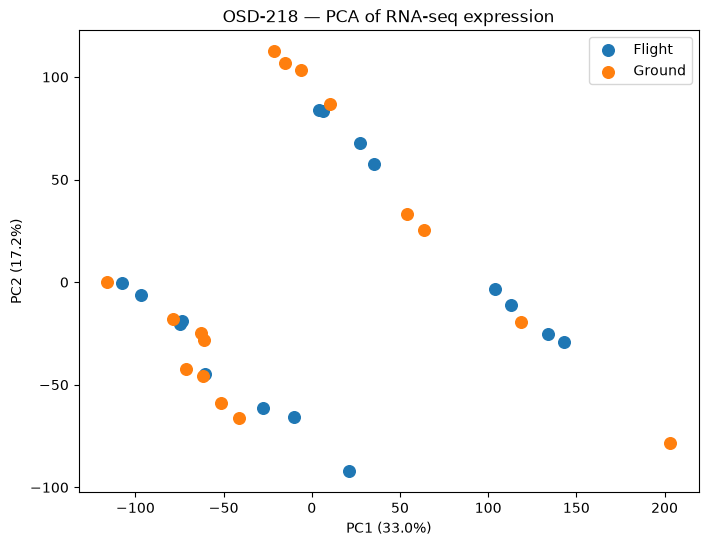

In [94]:
fig, ax = plt.subplots(figsize=(8, 6))

for group in pca_df["spaceflight"].unique():

    subset = pca_df[
        pca_df["spaceflight"] == group
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=group,
        s=70
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

ax.set_title(
    "OSD-218 — PCA of RNA-seq expression"
)

ax.legend()

plt.show()

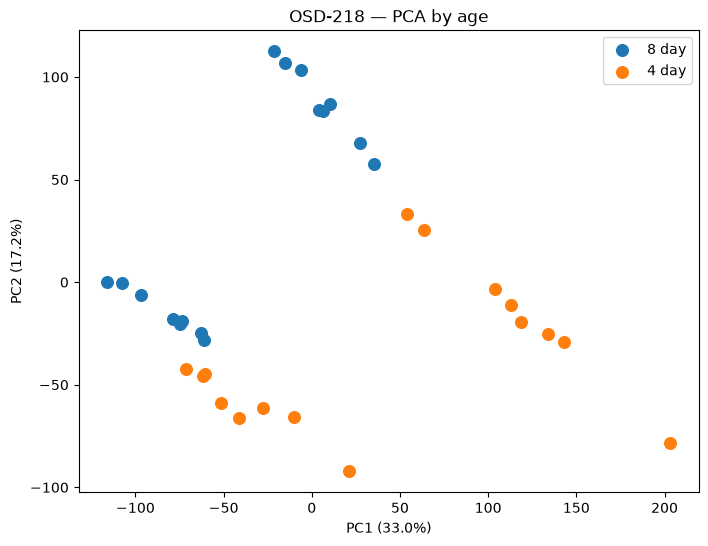

In [95]:
fig, ax = plt.subplots(figsize=(8, 6))

for group in pca_df["age"].unique():

    subset = pca_df[
        pca_df["age"] == group
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=group,
        s=70
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

ax.set_title(
    "OSD-218 — PCA by age"
)

ax.legend()

plt.show()

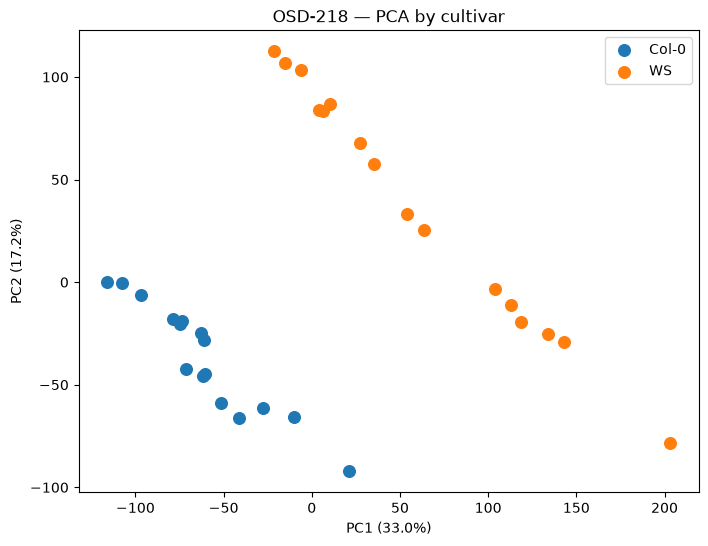

In [96]:
fig, ax = plt.subplots(figsize=(8, 6))

for group in pca_df["cultivar"].unique():

    subset = pca_df[
        pca_df["cultivar"] == group
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=group,
        s=70
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

ax.set_title(
    "OSD-218 — PCA by cultivar"
)

ax.legend()

plt.show()

In [97]:
pca.explained_variance_ratio_

array([0.33042505, 0.17245382])

### Variance Stabilizing Transformation

Los conteos de RNA-seq presentan una relación entre media y varianza:
los genes con mayor expresión suelen presentar mayor varianza.

Por esta razón, el PCA no se realiza directamente sobre los conteos
crudos.

PyDESeq2 aplica una transformación estabilizadora de varianza (VST)
para reducir la dependencia entre media y varianza:

\[
K_{ij} \rightarrow h(K_{ij})
\]

La transformación busca estabilizar la varianza entre genes con
distintos niveles de expresión y facilitar comparaciones exploratorias
entre muestras.

In [98]:
dds.vst()

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 1.41 seconds.



In [99]:
vst_counts = pd.DataFrame(
    dds.layers["vst_counts"],
    index=dds.obs_names,
    columns=dds.var_names
)

vst_counts.shape

(32, 32833)

In [100]:
pca_vst = PCA(n_components=2)

pca_scores_vst = pca_vst.fit_transform(vst_counts)

pca_vst_df = pd.DataFrame(
    pca_scores_vst,
    index=vst_counts.index,
    columns=["PC1", "PC2"]
)

pca_vst_df = pca_vst_df.join(design218)

print(
    "Varianza explicada VST:",
    pca_vst.explained_variance_ratio_
)

Varianza explicada VST: [0.29539429 0.17795378]


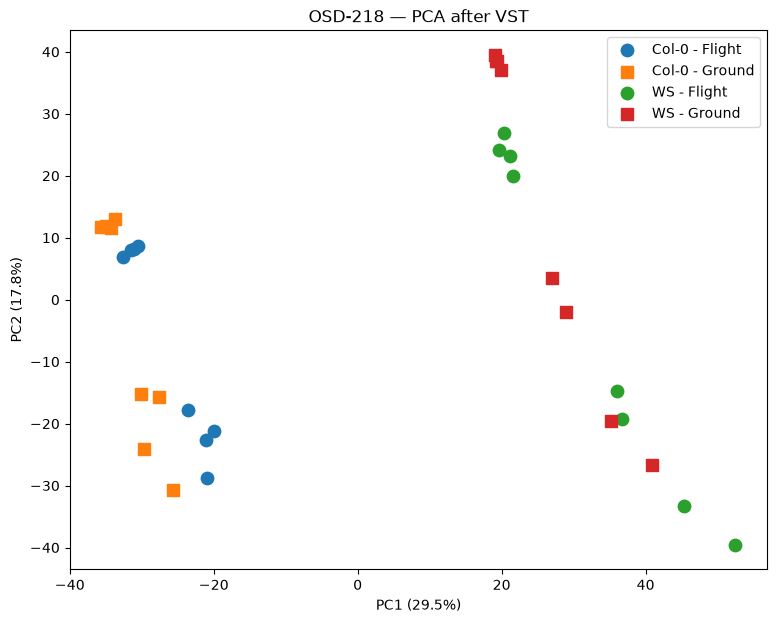

In [101]:
fig, ax = plt.subplots(figsize=(9, 7))

cultivars = pca_vst_df["cultivar"].unique()
conditions = pca_vst_df["spaceflight"].unique()

markers = {
    "Flight": "o",
    "Ground": "s"
}

for cultivar in cultivars:
    for condition in conditions:

        subset = pca_vst_df[
            (pca_vst_df["cultivar"] == cultivar) &
            (pca_vst_df["spaceflight"] == condition)
        ]

        ax.scatter(
            subset["PC1"],
            subset["PC2"],
            marker=markers[condition],
            s=80,
            label=f"{cultivar} - {condition}"
        )

ax.set_xlabel(
    f"PC1 ({pca_vst.explained_variance_ratio_[0]*100:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca_vst.explained_variance_ratio_[1]*100:.1f}%)"
)

ax.set_title(
    "OSD-218 — PCA after VST"
)

ax.legend()

plt.show()

### Interpretación del PCA de OSD-218

Los dos primeros componentes explican aproximadamente la mitad de la
variación transcriptómica observada.

La estructura visual sugiere que cultivar y edad explican una fracción
importante de la variación global.

La separación entre Flight y Ground es menos evidente en los primeros
componentes.

Esto no contradice la existencia de genes diferencialmente expresados:
el PCA caracteriza la variación global de todas las variables,
mientras que el análisis diferencial evalúa cada gen individualmente
mediante un modelo estadístico.

### Distancia en el espacio PCA

Como diagnóstico exploratorio se calcula la distancia euclidiana de
cada muestra al origen de los dos primeros componentes:

\[
d_i = \sqrt{PC1_i^2 + PC2_i^2}
\]

Un valor elevado indica que una muestra ocupa una posición extrema
dentro del plano PC1-PC2.

Esta métrica **no constituye una prueba estadística de outlier**.

Una muestra puede estar alejada del origen porque pertenece a un grupo
biológicamente distinto.

Para evaluar posibles muestras problemáticas se deben considerar
adicionalmente:

- consistencia entre réplicas,
- distancia al centroide del grupo,
- profundidad de secuenciación,
- métricas MultiQC,
- tasa de alineamiento,
- Cook's distance.

In [102]:
pca_vst_df["distance"] = np.sqrt(
    pca_vst_df["PC1"]**2 +
    pca_vst_df["PC2"]**2
)

pca_vst_df.sort_values(
    "distance",
    ascending=False
).head(5)

,PC1,PC2,spaceflight,age,cultivar,distance
Sample Name,,,,,,
SAMN06465160,52.479291,-39.586602,Flight,4 day,WS,65.735645
SAMN06465168,45.391259,-33.248369,Flight,4 day,WS,56.265624
SAMN06465174,40.847188,-26.629801,Ground,4 day,WS,48.761040
SAMN06465273,19.132010,39.487180,Ground,8 day,WS,43.877912
SAMN06465272,19.366672,38.501126,Ground,8 day,WS,43.097618


## Cook's distance

Cook's distance mide la influencia que una observación tiene sobre
el ajuste de un modelo estadístico.

En el contexto de DESeq2 se utiliza para identificar combinaciones
gen–muestra cuya presencia modifica de forma desproporcionada la
estimación del modelo.

Conceptualmente:

\[
D_{ij} \propto
\frac{
(\hat{\beta}-\hat{\beta}_{(-j)})^T
X^TX
(\hat{\beta}-\hat{\beta}_{(-j)})
}{
p\sigma^2
}
\]

donde la estimación del modelo completo se compara con la estimación
obtenida al retirar una observación.

Una muestra con posición extrema en PCA no necesariamente presenta
Cook's distance elevado.

Por tanto:

- PCA detecta estructura global de expresión.
- Cook's distance evalúa influencia sobre el modelo estadístico.

In [103]:
# Máximo Cook's distance por muestra
cooks = pd.DataFrame(
    dds.layers["cooks"],
    index=dds.obs_names,
    columns=dds.var_names
)

max_cooks_per_sample = cooks.max(axis=1).sort_values(ascending=False)

max_cooks_per_sample.head(10)

Sample Name
SAMN06465152    1.925342e+27
SAMN06465201    5.892775e+22
SAMN06465157    3.310113e+18
SAMN06465179    3.602897e+15
SAMN06465148    2.945644e+15
SAMN06465146    3.533680e+14
SAMN06465272    5.964255e+12
SAMN06465276    5.341713e+10
SAMN06465155    7.021183e+09
SAMN06465142    3.145206e+09
dtype: float64

## Evaluación de influencia por muestra

Cook's distance cuantifica cuánto influye una observación sobre el ajuste
del modelo estadístico de expresión diferencial.

Un valor elevado de Cook's distance no implica automáticamente que una
muestra deba excluirse. Su interpretación debe complementarse con:

- posición en PCA,
- consistencia con las réplicas biológicas,
- distancia al centroide del grupo,
- métricas de calidad de secuenciación,
- profundidad de lectura,
- tasa de alineamiento.

Por ello, las muestras potencialmente influyentes se revisan mediante
múltiples criterios antes de considerar cualquier exclusión.

In [104]:
cooks_summary = pd.DataFrame({
    "max_cooks": max_cooks_per_sample
}).join(design218)

cooks_summary.head(10)

,max_cooks,spaceflight,age,cultivar
Sample Name,,,,
SAMN06465152,1.925342e+27,Ground,8 day,Col-0
SAMN06465201,5.892775e+22,Ground,4 day,Col-0
SAMN06465157,3.310113e+18,Ground,8 day,Col-0
SAMN06465179,3.602897e+15,Ground,4 day,Col-0
SAMN06465148,2.945644e+15,Flight,8 day,Col-0
SAMN06465146,3.533680e+14,Flight,8 day,Col-0
SAMN06465272,5.964255e+12,Ground,8 day,WS
SAMN06465276,5.341713e+10,Ground,8 day,WS
SAMN06465155,7.021183e+09,Ground,8 day,Col-0


In [105]:
cooks_summary.sort_values(
    "max_cooks",
    ascending=False
).head(10)

,max_cooks,spaceflight,age,cultivar
Sample Name,,,,
SAMN06465152,1.925342e+27,Ground,8 day,Col-0
SAMN06465201,5.892775e+22,Ground,4 day,Col-0
SAMN06465157,3.310113e+18,Ground,8 day,Col-0
SAMN06465179,3.602897e+15,Ground,4 day,Col-0
SAMN06465148,2.945644e+15,Flight,8 day,Col-0
SAMN06465146,3.533680e+14,Flight,8 day,Col-0
SAMN06465272,5.964255e+12,Ground,8 day,WS
SAMN06465276,5.341713e+10,Ground,8 day,WS
SAMN06465155,7.021183e+09,Ground,8 day,Col-0


## Distancia al centroide del grupo experimental

La distancia al origen del PCA indica qué tan extrema es una muestra
dentro del plano PC1-PC2, pero no evalúa directamente su relación con
sus réplicas.

Para evaluar consistencia dentro de cada combinación experimental se
calcula la distancia de cada muestra al centroide de su grupo:

$$
d_{i,g} =
\sqrt{
(PC1_i - \overline{PC1}_g)^2 +
(PC2_i - \overline{PC2}_g)^2
}
$$

donde:

- $i$ representa una muestra,
- $g$ representa su grupo experimental,
- $\overline{PC1}_g$ y $\overline{PC2}_g$ son las coordenadas promedio
  del grupo.

Una distancia elevada respecto al centroide sugiere que una muestra es
menos consistente con sus réplicas biológicas.

In [106]:
group_cols = [
    "spaceflight",
    "age",
    "cultivar"
]

centroids = (
    pca_vst_df
    .groupby(group_cols)[["PC1", "PC2"]]
    .mean()
    .rename(
        columns={
            "PC1": "centroid_PC1",
            "PC2": "centroid_PC2"
        }
    )
)

pca_centroid = pca_vst_df.join(
    centroids,
    on=group_cols
)

pca_centroid["distance_to_centroid"] = np.sqrt(
    (pca_centroid["PC1"] - pca_centroid["centroid_PC1"])**2 +
    (pca_centroid["PC2"] - pca_centroid["centroid_PC2"])**2
)

pca_centroid[
    [
        "PC1",
        "PC2",
        "spaceflight",
        "age",
        "cultivar",
        "distance_to_centroid"
    ]
].sort_values(
    "distance_to_centroid",
    ascending=False
).head(10)

,PC1,PC2,spaceflight,age,cultivar,distance_to_centroid
Sample Name,,,,,,
SAMN06465174,40.847188,-26.629801,Ground,4 day,WS,17.321605
SAMN06465160,52.479291,-39.586602,Flight,4 day,WS,16.214284
SAMN06465177,26.968776,3.469893,Ground,4 day,WS,15.850318
SAMN06465163,36.011014,-14.677557,Flight,4 day,WS,13.725194
SAMN06465170,28.917773,-1.973314,Ground,4 day,WS,10.078409
SAMN06465197,-25.672408,-30.639410,Ground,4 day,Col-0,9.600448
SAMN06465165,36.739091,-19.237053,Flight,4 day,WS,9.513544
SAMN06465172,35.247982,-19.626720,Ground,4 day,WS,8.732267
SAMN06465168,45.391259,-33.248369,Flight,4 day,WS,7.108628


In [107]:
qc_samples = (
    pca_centroid[
        [
            "spaceflight",
            "age",
            "cultivar",
            "distance_to_centroid"
        ]
    ]
    .join(
        cooks_summary[["max_cooks"]]
    )
)

qc_samples.sort_values(
    "distance_to_centroid",
    ascending=False
).head(10)

,spaceflight,age,cultivar,distance_to_centroid,max_cooks
Sample Name,,,,,
SAMN06465174,Ground,4 day,WS,17.321605,2.477059e+01
SAMN06465160,Flight,4 day,WS,16.214284,8.745788e+00
SAMN06465177,Ground,4 day,WS,15.850318,1.671755e+01
SAMN06465163,Flight,4 day,WS,13.725194,3.239411e+00
SAMN06465170,Ground,4 day,WS,10.078409,1.483835e+05
SAMN06465197,Ground,4 day,Col-0,9.600448,7.543254e+01
SAMN06465165,Flight,4 day,WS,9.513544,7.907565e+00
SAMN06465172,Ground,4 day,WS,8.732267,7.382098e+06
SAMN06465168,Flight,4 day,WS,7.108628,1.680615e+01


In [108]:
qc_samples.sort_values(
    "distance_to_centroid",
    ascending=False
).head(10)

,spaceflight,age,cultivar,distance_to_centroid,max_cooks
Sample Name,,,,,
SAMN06465174,Ground,4 day,WS,17.321605,2.477059e+01
SAMN06465160,Flight,4 day,WS,16.214284,8.745788e+00
SAMN06465177,Ground,4 day,WS,15.850318,1.671755e+01
SAMN06465163,Flight,4 day,WS,13.725194,3.239411e+00
SAMN06465170,Ground,4 day,WS,10.078409,1.483835e+05
SAMN06465197,Ground,4 day,Col-0,9.600448,7.543254e+01
SAMN06465165,Flight,4 day,WS,9.513544,7.907565e+00
SAMN06465172,Ground,4 day,WS,8.732267,7.382098e+06
SAMN06465168,Flight,4 day,WS,7.108628,1.680615e+01


### Interpretación de Cook's distance por muestra

Cook's distance se calcula para cada combinación gen–muestra.

El valor máximo por muestra puede estar dominado por un único gen y,
por tanto, no constituye por sí solo un criterio adecuado para excluir
una muestra completa.

Para evaluar la influencia global de una muestra se consideran también:

- mediana de Cook's distance,
- percentiles altos (95% y 99%),
- número de genes con Cook's distance elevado,
- distancia al centroide de las réplicas,
- métricas técnicas de secuenciación.

La exclusión de una muestra requiere evidencia convergente de múltiples
criterios.

In [109]:
cooks_sample_stats = pd.DataFrame({
    "median_cooks": cooks.median(axis=1),
    "p95_cooks": cooks.quantile(0.95, axis=1),
    "p99_cooks": cooks.quantile(0.99, axis=1),
    "max_cooks": cooks.max(axis=1)
})

cooks_sample_stats = cooks_sample_stats.join(design218)

cooks_sample_stats.sort_values(
    "p99_cooks",
    ascending=False
).head(10)

,median_cooks,p95_cooks,p99_cooks,max_cooks,spaceflight,age,cultivar
Sample Name,,,,,,,
SAMN06465160,0.008556,0.109594,0.319519,8.745788e+00,Flight,4 day,WS
SAMN06465174,0.009747,0.119907,0.301932,2.477059e+01,Ground,4 day,WS
SAMN06465177,0.009924,0.102608,0.277368,1.671755e+01,Ground,4 day,WS
SAMN06465163,0.008148,0.086970,0.250685,3.239411e+00,Flight,4 day,WS
SAMN06465170,0.009505,0.086513,0.250145,1.483835e+05,Ground,4 day,WS
SAMN06465201,0.009000,0.088181,0.239850,5.892775e+22,Ground,4 day,Col-0
SAMN06465187,0.008366,0.075883,0.234624,4.229706e+02,Flight,4 day,Col-0
SAMN06465172,0.009718,0.097705,0.227849,7.382098e+06,Ground,4 day,WS
SAMN06465197,0.009531,0.085862,0.214806,7.543254e+01,Ground,4 day,Col-0


In [110]:
from scipy.stats import f

n_samples = 32
n_parameters = 4

cooks_cutoff = f.ppf(
    0.99,
    n_parameters,
    n_samples - n_parameters
)

print("Cook's cutoff:", cooks_cutoff)

Cook's cutoff: 4.074031774919609


In [111]:
n_high_cooks = (
    cooks > cooks_cutoff
).sum(axis=1)

cooks_sample_stats["n_genes_high_cooks"] = n_high_cooks

cooks_sample_stats[
    [
        "spaceflight",
        "age",
        "cultivar",
        "median_cooks",
        "p99_cooks",
        "n_genes_high_cooks",
        "max_cooks"
    ]
].sort_values(
    "n_genes_high_cooks",
    ascending=False
).head(15)

,spaceflight,age,cultivar,median_cooks,p99_cooks,n_genes_high_cooks,max_cooks
Sample Name,,,,,,,
SAMN06465272,Ground,8 day,WS,0.008048,0.196497,10,5.964255e+12
SAMN06465148,Flight,8 day,Col-0,0.005666,0.135843,10,2.945644e+15
SAMN06465152,Ground,8 day,Col-0,0.007318,0.207994,10,1.925342e+27
SAMN06465157,Ground,8 day,Col-0,0.005530,0.157761,8,3.310113e+18
SAMN06465142,Flight,8 day,Col-0,0.005957,0.146114,7,3.145206e+09
SAMN06465172,Ground,4 day,WS,0.009718,0.227849,6,7.382098e+06
SAMN06465201,Ground,4 day,Col-0,0.009000,0.239850,6,5.892775e+22
SAMN06465194,Ground,4 day,Col-0,0.007961,0.162283,6,1.474685e+07
SAMN06465179,Ground,4 day,Col-0,0.008009,0.160220,6,3.602897e+15


In [112]:
qc_samples = (
    pca_centroid[
        [
            "spaceflight",
            "age",
            "cultivar",
            "distance_to_centroid"
        ]
    ]
    .join(
        cooks_sample_stats[
            [
                "median_cooks",
                "p99_cooks",
                "n_genes_high_cooks",
                "max_cooks"
            ]
        ]
    )
)

qc_samples.sort_values(
    "distance_to_centroid",
    ascending=False
).head(15)

,spaceflight,age,cultivar,distance_to_centroid,median_cooks,p99_cooks,n_genes_high_cooks,max_cooks
Sample Name,,,,,,,,
SAMN06465174,Ground,4 day,WS,17.321605,0.009747,0.301932,1,2.477059e+01
SAMN06465160,Flight,4 day,WS,16.214284,0.008556,0.319519,4,8.745788e+00
SAMN06465177,Ground,4 day,WS,15.850318,0.009924,0.277368,3,1.671755e+01
SAMN06465163,Flight,4 day,WS,13.725194,0.008148,0.250685,0,3.239411e+00
SAMN06465170,Ground,4 day,WS,10.078409,0.009505,0.250145,4,1.483835e+05
SAMN06465197,Ground,4 day,Col-0,9.600448,0.009531,0.214806,5,7.543254e+01
SAMN06465165,Flight,4 day,WS,9.513544,0.008116,0.209508,2,7.907565e+00
SAMN06465172,Ground,4 day,WS,8.732267,0.009718,0.227849,6,7.382098e+06
SAMN06465168,Flight,4 day,WS,7.108628,0.007554,0.178062,4,1.680615e+01


### Interpretación integrada del control de calidad

La evaluación conjunta de PCA y Cook's distance no muestra evidencia
suficiente para excluir muestras completas en esta etapa.

Aunque algunas muestras presentan valores máximos de Cook's distance
muy elevados, estos valores están concentrados en un número reducido
de genes.

Las estadísticas robustas por muestra muestran:

- medianas de Cook's distance bajas,
- percentiles 99 bajos,
- pocos genes por muestra por encima del umbral de influencia.

Además, las mayores distancias al centroide se concentran
principalmente en muestras WS de 4 días, lo que sugiere una estructura
biológica asociada con cultivar y edad.

Por tanto, no se excluyen muestras en esta fase.

Cualquier decisión de exclusión requerirá evidencia adicional basada en:

- MultiQC,
- profundidad de secuenciación,
- tasa de alineamiento,
- distribución de tamaño de biblioteca,
- consistencia de las réplicas biológicas.

## Tamaño de biblioteca

El tamaño de biblioteca resume la cantidad total de conteos asignados a genes
en cada muestra:

$$
L_j = \sum_{i=1}^{G} K_{ij}
$$

donde:

- $L_j$ es el tamaño de biblioteca de la muestra $j$,
- $K_{ij}$ es el conteo del gen $i$ en la muestra $j$,
- $G$ es el número total de genes.

En este análisis, el tamaño de biblioteca se calcula a partir de los conteos
STAR utilizados para expresión diferencial.

Por tanto, no representa necesariamente el número total de reads generados
por el secuenciador, sino la cantidad de señal de secuenciación finalmente
representada en la matriz de conteos génicos.

Muestras con tamaños de biblioteca extremadamente bajos respecto a sus
réplicas pueden indicar problemas de profundidad, alineamiento o asignación
de reads y deben revisarse junto con las métricas de MultiQC.

In [113]:
library_size = counts_matrix.sum(axis=1)

library_qc = pd.DataFrame({
    "library_size": library_size,
    "library_size_millions": library_size / 1_000_000
}).join(design218)

library_qc.sort_values(
    "library_size",
    ascending=True
).head(10)

,library_size,library_size_millions,spaceflight,age,cultivar
SAMN06465174,7014790,7.014790,Ground,4 day,WS
SAMN06465168,9468624,9.468624,Flight,4 day,WS
SAMN06465160,10281176,10.281176,Flight,4 day,WS
SAMN06465165,10850306,10.850306,Flight,4 day,WS
SAMN06465163,11326900,11.326900,Flight,4 day,WS
SAMN06465181,11528337,11.528337,Flight,4 day,Col-0
SAMN06465172,11843187,11.843187,Ground,4 day,WS
SAMN06465183,12383883,12.383883,Flight,4 day,Col-0
SAMN06465177,13042111,13.042111,Ground,4 day,WS
SAMN06465268,13322311,13.322311,Flight,8 day,WS


In [114]:
library_qc["library_size_millions"].describe()

count    32.000000
mean     14.419697
std       2.900653
min       7.014790
25%      12.877554
50%      14.807320
75%      16.642474
max      19.716308
Name: library_size_millions, dtype: float64

In [115]:
library_group_summary = (
    library_qc
    .groupby(
        ["spaceflight", "age", "cultivar"]
    )["library_size_millions"]
    .agg(["count", "mean", "std", "min", "max"])
)

library_group_summary

count       mean       std        min        max
spaceflight age   cultivar                                                  
Flight      4 day Col-0         4  13.535730  2.307629  11.528337  16.792949
                  WS            4  10.481751  0.799326   9.468624  11.326900
            8 day Col-0         4  16.410192  1.619805  14.990405  18.407266
                  WS            4  14.393987  0.966594  13.322311  15.516766
Ground      4 day Col-0         4  16.500768  0.682771  15.732694  17.323638
                  WS            4  11.307325  2.933173   7.014790  13.329212
            8 day Col-0         4  15.506829  2.851072  13.640975  19.716308
                  WS            4  17.220994  1.578250  15.289044  18.762682

In [116]:
library_group_summary["CV_pct"] = (
    library_group_summary["std"] /
    library_group_summary["mean"]
) * 100

library_group_summary

count       mean       std        min        max  \
spaceflight age   cultivar                                                     
Flight      4 day Col-0         4  13.535730  2.307629  11.528337  16.792949   
                  WS            4  10.481751  0.799326   9.468624  11.326900   
            8 day Col-0         4  16.410192  1.619805  14.990405  18.407266   
                  WS            4  14.393987  0.966594  13.322311  15.516766   
Ground      4 day Col-0         4  16.500768  0.682771  15.732694  17.323638   
                  WS            4  11.307325  2.933173   7.014790  13.329212   
            8 day Col-0         4  15.506829  2.851072  13.640975  19.716308   
                  WS            4  17.220994  1.578250  15.289044  18.762682   

                               CV_pct  
spaceflight age   cultivar             
Flight      4 day Col-0     17.048426  
                  WS         7.625882  
            8 day Col-0      9.870726  
                  WS         6.715265  
Ground      4 day Col-0      4.137813  
                  WS        25.940469  
            8 day Col-0     18.385911  
                  WS         9.164686

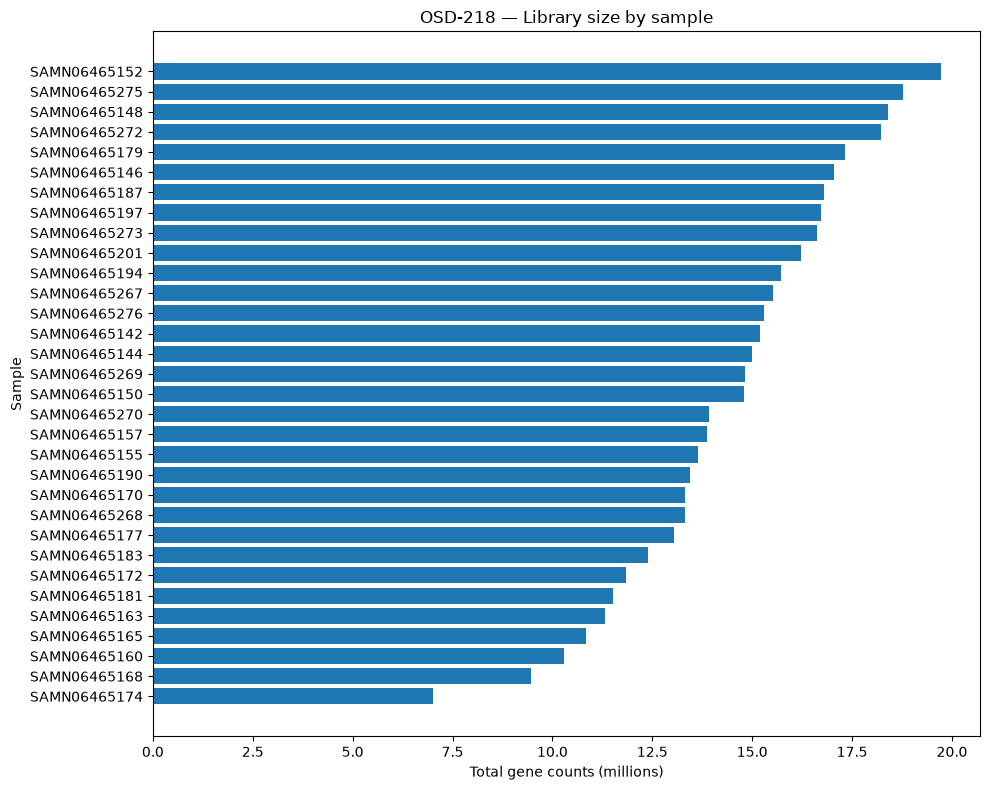

In [117]:
library_plot = library_qc.sort_values(
    "library_size_millions"
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    library_plot.index,
    library_plot["library_size_millions"]
)

ax.set_xlabel("Total gene counts (millions)")
ax.set_ylabel("Sample")
ax.set_title("OSD-218 — Library size by sample")

plt.tight_layout()
plt.show()

In [118]:
qc_integrated = (
    qc_samples
    .join(
        library_qc[
            ["library_size", "library_size_millions"]
        ]
    )
)

qc_integrated[
    [
        "spaceflight",
        "age",
        "cultivar",
        "library_size_millions",
        "distance_to_centroid",
        "median_cooks",
        "p99_cooks",
        "n_genes_high_cooks",
        "max_cooks"
    ]
].sort_values(
    "library_size_millions"
)

,spaceflight,age,cultivar,library_size_millions,distance_to_centroid,median_cooks,p99_cooks,n_genes_high_cooks,max_cooks
Sample Name,,,,,,,,,
SAMN06465174,Ground,4 day,WS,7.014790,17.321605,0.009747,0.301932,1,2.477059e+01
SAMN06465168,Flight,4 day,WS,9.468624,7.108628,0.007554,0.178062,4,1.680615e+01
SAMN06465160,Flight,4 day,WS,10.281176,16.214284,0.008556,0.319519,4,8.745788e+00
SAMN06465165,Flight,4 day,WS,10.850306,9.513544,0.008116,0.209508,2,7.907565e+00
SAMN06465163,Flight,4 day,WS,11.326900,13.725194,0.008148,0.250685,0,3.239411e+00
SAMN06465181,Flight,4 day,Col-0,11.528337,6.205890,0.007437,0.171926,1,1.355828e+01
SAMN06465172,Ground,4 day,WS,11.843187,8.732267,0.009718,0.227849,6,7.382098e+06
SAMN06465183,Flight,4 day,Col-0,12.383883,1.982787,0.006084,0.157986,1,2.920255e+01
SAMN06465177,Ground,4 day,WS,13.042111,15.850318,0.009924,0.277368,3,1.671755e+01


### Criterio de evaluación de muestras

Ninguna muestra se excluye únicamente por una métrica aislada.

Una muestra será considerada potencialmente problemática cuando exista
evidencia convergente entre varios indicadores, por ejemplo:

1. tamaño de biblioteca marcadamente reducido,
2. elevada distancia respecto al centroide de sus réplicas,
3. número elevado de genes con Cook's distance alto,
4. baja tasa de alineamiento,
5. problemas observados en FastQC/MultiQC,
6. profundidad de secuenciación anormalmente baja.

La exclusión de una réplica deberá estar respaldada por evidencia técnica
y documentada explícitamente.

### Interpretación del tamaño de biblioteca

Los tamaños de biblioteca presentan una distribución general relativamente
homogénea, con una media de aproximadamente 14.4 millones de conteos
por muestra.

La mayor variabilidad se observa en el grupo:

**Ground / 4 day / WS**

con un coeficiente de variación cercano al 26%.

Este mismo grupo contiene varias muestras que previamente mostraron
distancias elevadas respecto al centroide de sus réplicas.

Por tanto, este grupo requiere revisión técnica adicional mediante
métricas de calidad de secuenciación y alineamiento antes de considerar
cualquier exclusión.

No se excluyen muestras en esta etapa.

In [119]:
library_qc.sort_values(
    "library_size_millions"
).head(8)

,library_size,library_size_millions,spaceflight,age,cultivar
SAMN06465174,7014790,7.014790,Ground,4 day,WS
SAMN06465168,9468624,9.468624,Flight,4 day,WS
SAMN06465160,10281176,10.281176,Flight,4 day,WS
SAMN06465165,10850306,10.850306,Flight,4 day,WS
SAMN06465163,11326900,11.326900,Flight,4 day,WS
SAMN06465181,11528337,11.528337,Flight,4 day,Col-0
SAMN06465172,11843187,11.843187,Ground,4 day,WS
SAMN06465183,12383883,12.383883,Flight,4 day,Col-0


### Muestra prioritaria para revisión técnica

La muestra `SAMN06465174` presenta el menor tamaño de biblioteca del
experimento, con aproximadamente 7.0 millones de conteos.

Además, mostró la mayor distancia respecto al centroide de su grupo
experimental (`Ground / 4 day / WS`).

Sin embargo, sus métricas robustas de Cook's distance no indican una
influencia generalizada sobre el modelo.

Por tanto, la muestra se mantiene provisionalmente en el análisis y
se prioriza para revisión mediante métricas de calidad de secuenciación,
trimming y alineamiento.

### Recuperación del manifiesto después de reiniciar el kernel

Las variables almacenadas en memoria se pierden cuando el kernel de
Jupyter se reinicia.

Para garantizar reproducibilidad, los archivos intermedios importantes
se guardan en disco y se vuelven a cargar cuando son necesarios.

En este caso, el manifiesto de archivos de OSD-218 se recupera desde:

`metadata/OSD-218_file_manifest.csv`

In [120]:
import pandas as pd
from pathlib import Path

manifest_path = Path("../metadata/OSD-218_file_manifest.csv")

manifest218 = pd.read_csv(manifest_path)

manifest218.head()

,category,date_created,date_updated,file_name,file_size,organization,remote_url,restricted,subcategory,subdirectory,visible,download_url
0,Study Metadata Files,1.787195e+09,1.787195e+09,OSD-218_metadata_OSD-218-ISA.zip,149299,OSD,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=OSD-218_metadata_OSD-218-ISA.zip,False,NaN,NaN,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=OSD-218_metadata_OSD-218-ISA.zip
1,GeneLab Processed RNA-Seq Files,1.787195e+09,1.787195e+09,GLDS-218_rna_seq_processed_md5sum_GLbulkRNAseq.tsv,38547,genelab,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_processed_md5sum_GLbulkRNAseq.tsv,False,MD5 Checksums,NaN,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_processed_md5sum_GLbulkRNAseq.tsv
2,GeneLab Processed RNA-Seq Files,1.787195e+09,1.787195e+09,GLDS-218_rna_seq_software_versions_GLbulkRNAseq.md,3051,genelab,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_software_versions_GLbulkRNAseq.md,False,Processing Info,NaN,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_software_versions_GLbulkRNAseq.md
3,GeneLab Processed RNA-Seq Files,1.787195e+09,1.787195e+09,GLDS-218_rna_seq_processing_info_GLbulkRNAseq.zip,15967,genelab,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_processing_info_GLbulkRNAseq.zip,False,Processing Info,NaN,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_processing_info_GLbulkRNAseq.zip
4,GeneLab Processed RNA-Seq Files,1.787195e+09,1.787195e+09,GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv,11617,genelab,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv,False,Processing Info,NaN,True,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_bulkRNASeq_v2_runsheet.csv


In [121]:
multiqc_files = manifest218[
    manifest218["file_name"]
    .str.contains("multiqc", case=False, na=False)
][
    ["file_name", "file_size", "remote_url", "download_url"]
]

multiqc_files

,file_name,file_size,remote_url,download_url
69,GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip,786681,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip
70,GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq.html,5594135,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq.html,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq.html
234,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip,26845,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip
235,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html,4617305,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html
236,GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip,28788,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip
237,GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq.html,4589616,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq.html,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq.html
238,GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip,133119,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip
239,GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq.html,4644745,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq.html,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq.html
240,GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq_data.zip,5577,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq_data.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq_data.zip
241,GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq.html,4582710,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq.html,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq.html


In [122]:
qc_files = manifest218[
    manifest218["file_name"]
    .str.contains(
        "multiqc|fastqc|quality|trim|star|alignment",
        case=False,
        na=False,
        regex=True
    )
][
    ["file_name", "file_size", "remote_url", "download_url"]
]

qc_files.sort_values("file_name")

,file_name,file_size,remote_url,download_url
235,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html,4617305,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html
234,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip,26845,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip
134,GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_R1_trimmed.fastq.gz,1023817231,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_R1_trimmed.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_R1_trimmed.fastq.gz
133,GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_R2_trimmed.fastq.gz,1046402680,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_R2_trimmed.fastq.gz,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465142_GLbulkRNAseq_R2_trimmed.fastq.gz
68,GLDS-218_rna_seq_SAMN06465142_R1_GLbulkRNAseq_trimming_report.txt,3277,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465142_R1_GLbulkRNAseq_trimming_report.txt,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_SAMN06465142_R1_GLbulkRNAseq_trimming_report.txt
...,...,...,...,...
249,GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip,682975,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip
237,GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq.html,4589616,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq.html,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq.html
236,GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip,28788,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip
70,GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq.html,5594135,/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq.html,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq.html


In [123]:
multiqc_reports = manifest218[
    manifest218["file_name"]
    .str.contains("multiqc", case=False, na=False)
][
    ["file_name", "file_size", "download_url"]
].copy()

pd.set_option("display.max_colwidth", None)

multiqc_reports.sort_values("file_name")

,file_name,file_size,download_url
235,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html,4617305,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html
234,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip,26845,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip
384,GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq.html,4877572,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq.html
383,GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq_data.zip,46991,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq_data.zip
243,GLDS-218_rna_seq_geneBody_cov_multiqc_GLbulkRNAseq.html,4655667,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_geneBody_cov_multiqc_GLbulkRNAseq.html
242,GLDS-218_rna_seq_geneBody_cov_multiqc_GLbulkRNAseq_data.zip,161546,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_geneBody_cov_multiqc_GLbulkRNAseq_data.zip
241,GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq.html,4582710,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq.html
240,GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq_data.zip,5577,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq_data.zip
239,GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq.html,4644745,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq.html
238,GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip,133119,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip


In [124]:
for keyword in [
    "raw_multiqc",
    "trimmed_multiqc",
    "align_multiqc",
    "read_dist_multiqc",
    "RSEM_count_multiqc"
]:
    print(f"\n--- {keyword} ---")
    
    subset = multiqc_reports[
        multiqc_reports["file_name"]
        .str.contains(keyword, case=False, na=False)
    ]
    
    for _, row in subset.iterrows():
        print(row["file_name"], "|", row["file_size"])


--- raw_multiqc ---
GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip | 682975
GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq.html | 5507289

--- trimmed_multiqc ---
GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip | 786681
GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq.html | 5594135

--- align_multiqc ---
GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq_data.zip | 46991
GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq.html | 4877572

--- read_dist_multiqc ---
GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip | 28788
GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq.html | 4589616

--- RSEM_count_multiqc ---
GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip | 26845
GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq.html | 4617305


## Revisión de métricas técnicas de secuenciación

Después de evaluar la estructura transcriptómica, la consistencia entre
réplicas y la influencia estadística, se revisan las métricas técnicas
generadas por el pipeline GeneLab.

El objetivo principal es determinar si las muestras que presentan
características atípicas en la matriz de expresión también muestran
evidencia de problemas durante:

1. secuenciación,
2. control de calidad de reads,
3. trimming,
4. alineamiento,
5. asignación de reads a genes.

La muestra `SAMN06465174` se utiliza como caso prioritario debido a su
menor tamaño de biblioteca y elevada distancia respecto al centroide
de sus réplicas.

Sin embargo, ninguna muestra se considera técnicamente deficiente hasta
que exista evidencia convergente entre múltiples métricas.

### Selección de reportes MultiQC para análisis programático

Los archivos `*_data.zip` disponibles se descargan para conservar
las métricas técnicas generadas por GeneLab.

El análisis principal utiliza:

- Raw FastQC,
- Trimmed FastQC / Cutadapt,
- STAR alignment,
- RSeQC read distribution,
- RSEM.

También se conservan otros reportes RSeQC disponibles para análisis
posteriores.

In [125]:
multiqc_zips = multiqc_reports[
    multiqc_reports["file_name"]
    .str.endswith("_data.zip", na=False)
].copy()

multiqc_zips[
    ["file_name", "file_size", "download_url"]
]

,file_name,file_size,download_url
69,GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip,786681,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip
234,GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip,26845,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip
236,GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip,28788,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip
238,GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip,133119,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip
240,GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq_data.zip,5577,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq_data.zip
242,GLDS-218_rna_seq_geneBody_cov_multiqc_GLbulkRNAseq_data.zip,161546,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_geneBody_cov_multiqc_GLbulkRNAseq_data.zip
249,GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip,682975,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip
383,GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq_data.zip,46991,https://osdr.nasa.gov/geode-py/ws/studies/OSD-218/download?source=datamanager&file=GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq_data.zip


In [126]:
from pathlib import Path

multiqc_dir = Path("../data/processed/OSD-218/multiqc")
multiqc_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(multiqc_dir.resolve())

/Users/wilfredofariasjofre/Projects/NASA-PlantSpaceOmics/data/processed/OSD-218/multiqc


In [127]:
import requests

for _, row in multiqc_zips.iterrows():

    file_path = multiqc_dir / row["file_name"]

    if not file_path.exists():
        print("Downloading:", row["file_name"])

        response = requests.get(
            row["download_url"],
            timeout=120
        )

        response.raise_for_status()

        file_path.write_bytes(response.content)

    else:
        print("Already exists:", row["file_name"])

Already exists: GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip
Already exists: GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip
Already exists: GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip
Already exists: GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip
Already exists: GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq_data.zip
Already exists: GLDS-218_rna_seq_geneBody_cov_multiqc_GLbulkRNAseq_data.zip
Already exists: GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip
Already exists: GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq_data.zip


In [128]:
for f in multiqc_dir.glob("*.zip"):
    print(f.name, f.stat().st_size)

GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip 682975
GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip 26845
GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip 786681
GLDS-218_rna_seq_inner_dist_multiqc_GLbulkRNAseq_data.zip 133119
GLDS-218_rna_seq_infer_exp_multiqc_GLbulkRNAseq_data.zip 5577
GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip 28788
GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq_data.zip 46991
GLDS-218_rna_seq_geneBody_cov_multiqc_GLbulkRNAseq_data.zip 161546


In [129]:
import zipfile

for zip_path in multiqc_dir.glob("*.zip"):

    print("\n" + "=" * 80)
    print(zip_path.name)
    print("=" * 80)

    with zipfile.ZipFile(zip_path, "r") as z:
        for name in z.namelist():
            print(name)


GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip
raw_multiqc_GLbulkRNAseq_data/multiqc_general_stats.txt
raw_multiqc_GLbulkRNAseq_data/fastqc_overrepresented_sequences_plot.txt
raw_multiqc_GLbulkRNAseq_data/fastqc_per_base_sequence_quality_plot.txt
raw_multiqc_GLbulkRNAseq_data/fastqc_sequence_length_distribution_plot.txt
raw_multiqc_GLbulkRNAseq_data/fastqc-status-check-heatmap.txt
raw_multiqc_GLbulkRNAseq_data/fastqc_per_base_n_content_plot.txt
raw_multiqc_GLbulkRNAseq_data/multiqc_software_versions.txt
raw_multiqc_GLbulkRNAseq_data/fastqc_top_overrepresented_sequences_table.txt
raw_multiqc_GLbulkRNAseq_data/multiqc_fastqc.txt
raw_multiqc_GLbulkRNAseq_data/fastqc_adapter_content_plot.txt
raw_multiqc_GLbulkRNAseq_data/fastqc_per_sequence_gc_content_plot_Counts.txt
raw_multiqc_GLbulkRNAseq_data/fastqc_per_sequence_quality_scores_plot.txt
raw_multiqc_GLbulkRNAseq_data/fastqc_sequence_counts_plot.txt
raw_multiqc_GLbulkRNAseq_data/multiqc.log
raw_multiqc_GLbulkRNAseq_data/fastqc_sequen

### Fuentes de QC seleccionadas

La revisión técnica se realiza siguiendo las principales etapas del
pipeline de RNA-seq:

1. **Raw FastQC:** calidad de las lecturas originales.
2. **Trimmed FastQC / Cutadapt:** efecto del filtrado y eliminación de adaptadores.
3. **STAR alignment:** eficiencia y características del alineamiento.
4. **RSeQC read distribution:** distribución de lecturas entre regiones génicas.
5. **RSEM:** eficiencia de asignación y cuantificación.

Estas métricas se analizarán conjuntamente con el tamaño de biblioteca,
PCA y Cook's distance para determinar si alguna muestra presenta
evidencia técnica consistente de baja calidad.

In [130]:
import zipfile
import pandas as pd
from io import TextIOWrapper

def read_table_from_zip(zip_path, filename_suffix):
    
    with zipfile.ZipFile(zip_path, "r") as z:
        
        matches = [
            name for name in z.namelist()
            if name.endswith(filename_suffix)
        ]
        
        if len(matches) == 0:
            raise FileNotFoundError(
                f"No se encontró {filename_suffix} en {zip_path.name}"
            )
        
        print("Reading:", matches[0])
        
        with z.open(matches[0]) as f:
            return pd.read_csv(
                TextIOWrapper(f, encoding="utf-8"),
                sep="\t"
            )

In [131]:
raw_zip = next(
    multiqc_dir.glob("*raw_multiqc*_data.zip")
)

trimmed_zip = next(
    multiqc_dir.glob("*trimmed_multiqc*_data.zip")
)

align_zip = next(
    multiqc_dir.glob("*align_multiqc*_data.zip")
)

read_dist_zip = next(
    multiqc_dir.glob("*read_dist_multiqc*_data.zip")
)

rsem_zip = next(
    multiqc_dir.glob("*RSEM_count_multiqc*_data.zip")
)

print(raw_zip.name)
print(trimmed_zip.name)
print(align_zip.name)
print(read_dist_zip.name)
print(rsem_zip.name)

GLDS-218_rna_seq_raw_multiqc_GLbulkRNAseq_data.zip
GLDS-218_rna_seq_trimmed_multiqc_GLbulkRNAseq_data.zip
GLDS-218_rna_seq_align_multiqc_GLbulkRNAseq_data.zip
GLDS-218_rna_seq_read_dist_multiqc_GLbulkRNAseq_data.zip
GLDS-218_rna_seq_RSEM_count_multiqc_GLbulkRNAseq_data.zip


In [132]:
raw_stats = read_table_from_zip(
    raw_zip,
    "multiqc_general_stats.txt"
)

print(raw_stats.shape)
print(raw_stats.columns.tolist())

raw_stats.head()

Reading: raw_multiqc_GLbulkRNAseq_data/multiqc_general_stats.txt
(96, 7)
['Sample', 'fastqc-percent_duplicates', 'fastqc-percent_gc', 'fastqc-avg_sequence_length', 'fastqc-median_sequence_length', 'fastqc-percent_fails', 'fastqc-total_sequences']


,Sample,fastqc-percent_duplicates,fastqc-percent_gc,fastqc-avg_sequence_length,fastqc-median_sequence_length,fastqc-percent_fails,fastqc-total_sequences
0,SAMN06465142,65.174618,44.0,73.386067,76.0,20.0,47.346728
1,SAMN06465142 Read 1,67.097509,44.0,73.377111,76.0,20.0,23.673364
2,SAMN06465142 Read 2,63.251727,44.0,73.395023,76.0,20.0,23.673364
3,SAMN06465144,66.910635,44.5,74.088491,76.0,20.0,47.625572
4,SAMN06465144 Read 1,68.757651,44.0,74.087390,76.0,20.0,23.812786


In [133]:
trimmed_stats = read_table_from_zip(
    trimmed_zip,
    "multiqc_general_stats.txt"
)

print(trimmed_stats.shape)
print(trimmed_stats.columns.tolist())

trimmed_stats.head()

Reading: trimmed_multiqc_GLbulkRNAseq_data/multiqc_general_stats.txt
(96, 8)
['Sample', 'fastqc-percent_duplicates', 'fastqc-percent_gc', 'fastqc-avg_sequence_length', 'fastqc-median_sequence_length', 'fastqc-percent_fails', 'fastqc-total_sequences', 'cutadapt-percent_trimmed']


,Sample,fastqc-percent_duplicates,fastqc-percent_gc,fastqc-avg_sequence_length,fastqc-median_sequence_length,fastqc-percent_fails,fastqc-total_sequences,cutadapt-percent_trimmed
0,SAMN06465142,65.270409,44.0,72.810311,76.0,20.0,46.769592,1.848909
1,SAMN06465142 Read 1,67.083696,44.0,72.881347,76.0,20.0,23.384796,1.405500
2,SAMN06465142 Read 2,63.457122,44.0,72.739276,76.0,20.0,23.384796,2.292209
3,SAMN06465144,67.063755,44.5,73.497383,76.0,20.0,47.116548,1.731875
4,SAMN06465144 Read 1,68.788794,44.0,73.577478,76.0,20.0,23.558274,1.296342


In [134]:
align_stats = read_table_from_zip(
    align_zip,
    "multiqc_general_stats.txt"
)

print(align_stats.shape)
print(align_stats.columns.tolist())

align_stats.head()

Reading: align_multiqc_GLbulkRNAseq_data/multiqc_general_stats.txt
(32, 7)
['Sample', 'star-total_reads', 'star-mapped', 'star-mapped_percent', 'star-uniquely_mapped', 'star-uniquely_mapped_percent', 'star-multimapped']


,Sample,star-total_reads,star-mapped,star-mapped_percent,star-uniquely_mapped,star-uniquely_mapped_percent,star-multimapped
0,SAMN06465142,23.384796,21.475086,91.83,16.645629,71.18,4.829457
1,SAMN06465144,23.558274,21.763247,92.38,16.523825,70.14,5.239422
2,SAMN06465146,26.688321,24.411305,91.47,18.767700,70.32,5.643605
3,SAMN06465148,27.484570,25.451296,92.60,20.129326,73.24,5.321970
4,SAMN06465150,24.657664,22.588485,91.61,16.506315,66.94,6.082170


In [135]:
star_stats = read_table_from_zip(
    align_zip,
    "multiqc_star.txt"
)

print(star_stats.shape)
print(star_stats.columns.tolist())

star_stats.head()

Reading: align_multiqc_GLbulkRNAseq_data/multiqc_star.txt
(32, 29)
['Sample', 'total_reads', 'avg_input_read_length', 'uniquely_mapped', 'uniquely_mapped_percent', 'avg_mapped_read_length', 'num_splices', 'num_annotated_splices', 'num_GTAG_splices', 'num_GCAG_splices', 'num_ATAC_splices', 'num_noncanonical_splices', 'mismatch_rate', 'deletion_rate', 'deletion_length', 'insertion_rate', 'insertion_length', 'multimapped', 'multimapped_percent', 'multimapped_toomany', 'multimapped_toomany_percent', 'unmapped_mismatches_percent', 'unmapped_tooshort_percent', 'unmapped_other_percent', 'unmapped_mismatches', 'unmapped_tooshort', 'unmapped_other', 'mapped_percent', 'mapped']


,Sample,total_reads,avg_input_read_length,uniquely_mapped,uniquely_mapped_percent,avg_mapped_read_length,num_splices,num_annotated_splices,num_GTAG_splices,num_GCAG_splices,...,multimapped_toomany,multimapped_toomany_percent,unmapped_mismatches_percent,unmapped_tooshort_percent,unmapped_other_percent,unmapped_mismatches,unmapped_tooshort,unmapped_other,mapped_percent,mapped
0,SAMN06465142,23384796.0,145.0,16645629.0,71.18,143.91,7058558.0,7058238.0,6994829.0,51082.0,...,5472.0,0.02,0.0,8.13,0.01,0,1901899,2339,91.83,21475086.0
1,SAMN06465144,23558274.0,146.0,16523825.0,70.14,145.11,7166151.0,7165566.0,7103030.0,51243.0,...,3726.0,0.02,0.0,7.57,0.04,0,1781885,9416,92.38,21763247.0
2,SAMN06465146,26688321.0,145.0,18767700.0,70.32,144.03,7872352.0,7871343.0,7799394.0,57079.0,...,8610.0,0.03,0.0,8.48,0.02,0,2263069,5337,91.47,24411305.0
3,SAMN06465148,27484570.0,146.0,20129326.0,73.24,145.17,8880687.0,8880168.0,8801278.0,63997.0,...,5564.0,0.02,0.0,7.35,0.03,0,2019467,8243,92.60,25451296.0
4,SAMN06465150,24657664.0,145.0,16506315.0,66.94,144.05,6602131.0,6601556.0,6543227.0,43911.0,...,14837.0,0.06,0.0,8.31,0.02,0,2049410,4932,91.61,22588485.0


In [136]:
rsem_stats = read_table_from_zip(
    rsem_zip,
    "multiqc_rsem.txt"
)

print(rsem_stats.shape)
print(rsem_stats.columns.tolist())

rsem_stats.head()

Reading: RSEM_count_multiqc_GLbulkRNAseq_data/multiqc_rsem.txt
(32, 9)
['Sample', 'Unalignable', 'Alignable', 'Filtered', 'Total', 'alignable_percent', 'Unique', 'Multi', 'Uncertain']


,Sample,Unalignable,Alignable,Filtered,Total,alignable_percent,Unique,Multi,Uncertain
0,SAMN06465142,1909710,14520620,0,16430330,88.376922,13397496,1123124,6240192
1,SAMN06465144,1795027,14375374,0,16170401,88.899304,13252797,1122577,6204914
2,SAMN06465146,2277016,15884605,0,18161621,87.462485,14993183,891422,6591854
3,SAMN06465148,2033274,17578797,0,19612071,89.632538,16384589,1194208,7501596
4,SAMN06465150,2069179,14128187,0,16197366,87.225213,12888966,1239221,6065870


In [137]:
read_dist_stats = read_table_from_zip(
    read_dist_zip,
    "multiqc_rseqc_read_distribution.txt"
)

print(read_dist_stats.shape)
print(read_dist_stats.columns.tolist())

read_dist_stats.head()

Reading: read_dist_multiqc_GLbulkRNAseq_data/multiqc_rseqc_read_distribution.txt
(32, 46)
['Sample', 'total_reads', 'total_tags', 'total_assigned_tags', 'cds_exons_total_bases', 'cds_exons_tag_count', 'cds_exons_tags_kb', '5_utr_exons_total_bases', '5_utr_exons_tag_count', '5_utr_exons_tags_kb', '3_utr_exons_total_bases', '3_utr_exons_tag_count', '3_utr_exons_tags_kb', 'introns_total_bases', 'introns_tag_count', 'introns_tags_kb', 'tss_up_1kb_total_bases', 'tss_up_1kb_tag_count', 'tss_up_1kb_tags_kb', 'tss_up_5kb_tags_kb', 'tss_up_10kb_tags_kb', 'tes_down_1kb_total_bases', 'tes_down_1kb_tag_count', 'tes_down_1kb_tags_kb', 'tes_down_5kb_tags_kb', 'tes_down_10kb_tags_kb', 'other_intergenic_tag_count', 'cds_exons_tag_pct', '5_utr_exons_tag_pct', '3_utr_exons_tag_pct', 'introns_tag_pct', 'tss_up_1kb_tag_pct', 'tss_up_5kb_tag_pct', 'tss_up_10kb_tag_pct', 'tes_down_1kb_tag_pct', 'tes_down_5kb_tag_pct', 'tes_down_10kb_tag_pct', 'other_intergenic_tag_pct', 'tss_up_5kb-10kb_total_bases', 'tss_u

,Sample,total_reads,total_tags,total_assigned_tags,cds_exons_total_bases,cds_exons_tag_count,cds_exons_tags_kb,5_utr_exons_total_bases,5_utr_exons_tag_count,5_utr_exons_tags_kb,...,tes_down_10kb_tag_pct,other_intergenic_tag_pct,tss_up_5kb-10kb_total_bases,tss_up_1kb-5kb_total_bases,tss_up_5kb-10kb_tag_count,tss_up_1kb-5kb_tag_count,tes_down_5kb-10kb_total_bases,tes_down_1kb-5kb_total_bases,tes_down_5kb-10kb_tag_count,tes_down_1kb-5kb_tag_count
0,SAMN06465142,42928402,51638736,44242745,33774176,29463750,872.38,6603616,4645452,703.47,...,1.553810,14.322564,5925848,18791890,20014,5933,8093075,19493025,982,276557
1,SAMN06465144,43502644,52288521,43821416,33774176,29764939,881.29,6603616,4650448,704.23,...,1.638880,16.193047,5925848,18791890,7457,5824,8093075,19493025,875,285680
2,SAMN06465146,48792291,58805808,49086825,33774176,32925741,974.88,6603616,4284249,648.77,...,1.409349,16.527250,5925848,18791890,11701,12043,8093075,19493025,1405,321366
3,SAMN06465148,50874351,61690383,53380172,33774176,36795848,1089.47,6603616,5108577,773.60,...,1.368160,13.470837,5925848,18791890,8587,7685,8093075,19493025,1196,277514
4,SAMN06465150,45154859,53709601,43823806,33774176,28288963,837.59,6603616,5129764,776.81,...,1.947231,18.406011,5925848,18791890,22769,7504,8093075,19493025,14895,347143


In [138]:
print(raw_stats.columns.tolist())
print(trimmed_stats.columns.tolist())
print(star_stats.columns.tolist())
print(rsem_stats.columns.tolist())
print(read_dist_stats.columns.tolist())

['Sample', 'fastqc-percent_duplicates', 'fastqc-percent_gc', 'fastqc-avg_sequence_length', 'fastqc-median_sequence_length', 'fastqc-percent_fails', 'fastqc-total_sequences']
['Sample', 'fastqc-percent_duplicates', 'fastqc-percent_gc', 'fastqc-avg_sequence_length', 'fastqc-median_sequence_length', 'fastqc-percent_fails', 'fastqc-total_sequences', 'cutadapt-percent_trimmed']
['Sample', 'total_reads', 'avg_input_read_length', 'uniquely_mapped', 'uniquely_mapped_percent', 'avg_mapped_read_length', 'num_splices', 'num_annotated_splices', 'num_GTAG_splices', 'num_GCAG_splices', 'num_ATAC_splices', 'num_noncanonical_splices', 'mismatch_rate', 'deletion_rate', 'deletion_length', 'insertion_rate', 'insertion_length', 'multimapped', 'multimapped_percent', 'multimapped_toomany', 'multimapped_toomany_percent', 'unmapped_mismatches_percent', 'unmapped_tooshort_percent', 'unmapped_other_percent', 'unmapped_mismatches', 'unmapped_tooshort', 'unmapped_other', 'mapped_percent', 'mapped']
['Sample', 'Un

### Integración de métricas técnicas por muestra

Las tablas MultiQC provienen de diferentes etapas del pipeline y pueden utilizar
nombres de archivo diferentes para una misma muestra.

Antes de integrar las métricas, se normalizan los identificadores para recuperar
el código BioSample (`SAMN...`) de cada registro.

Esto permite combinar las métricas de FastQC, trimming, STAR, RSEM y RSeQC con
el diseño experimental y las métricas transcriptómicas calculadas previamente.

In [139]:
import re

def extract_samn(sample_name):
    match = re.search(r"(SAMN\d+)", str(sample_name))
    return match.group(1) if match else None

In [140]:
for df in [
    raw_stats,
    trimmed_stats,
    star_stats,
    rsem_stats,
    read_dist_stats
]:
    df["sample_id"] = df["Sample"].apply(extract_samn)

In [141]:
for name, df in {
    "raw": raw_stats,
    "trimmed": trimmed_stats,
    "STAR": star_stats,
    "RSEM": rsem_stats,
    "read_dist": read_dist_stats
}.items():
    print(name, df["sample_id"].nunique(), df["sample_id"].isna().sum())

raw 32 0
trimmed 32 0
STAR 32 0
RSEM 32 0
read_dist 32 0


In [142]:
print(raw_stats.shape)
print(trimmed_stats.shape)
print(star_stats.shape)
print(rsem_stats.shape)
print(read_dist_stats.shape)

(96, 8)
(96, 9)
(32, 30)
(32, 10)
(32, 47)


In [143]:
raw_stats["sample_id"].value_counts().head(10)

sample_id
SAMN06465142    3
SAMN06465144    3
SAMN06465275    3
SAMN06465273    3
SAMN06465272    3
SAMN06465270    3
SAMN06465269    3
SAMN06465268    3
SAMN06465267    3
SAMN06465201    3
Name: count, dtype: int64

In [144]:
trimmed_stats["sample_id"].value_counts().head(10)

sample_id
SAMN06465142    3
SAMN06465144    3
SAMN06465275    3
SAMN06465273    3
SAMN06465272    3
SAMN06465270    3
SAMN06465269    3
SAMN06465268    3
SAMN06465267    3
SAMN06465201    3
Name: count, dtype: int64

In [145]:
raw_stats["sample_id"].value_counts().value_counts()

count
3    32
Name: count, dtype: int64

In [146]:
trimmed_stats.loc[
    trimmed_stats["sample_id"] == "SAMN06465174",
    ["Sample", "sample_id"]
]

,Sample,sample_id
42,SAMN06465174,SAMN06465174
43,SAMN06465174 Read 1,SAMN06465174
44,SAMN06465174 Read 2,SAMN06465174


In [147]:
raw_stats.loc[
    raw_stats["sample_id"] == "SAMN06465174",
    ["Sample", "sample_id"]
]

,Sample,sample_id
42,SAMN06465174,SAMN06465174
43,SAMN06465174 Read 1,SAMN06465174
44,SAMN06465174 Read 2,SAMN06465174


In [148]:
raw_stats.loc[
    raw_stats["sample_id"] == "SAMN06465174",
    [
        "Sample",
        "fastqc-total_sequences",
        "fastqc-percent_duplicates",
        "fastqc-percent_gc",
        "fastqc-avg_sequence_length",
        "fastqc-percent_fails"
    ]
]

,Sample,fastqc-total_sequences,fastqc-percent_duplicates,fastqc-percent_gc,fastqc-avg_sequence_length,fastqc-percent_fails
42,SAMN06465174,38.245408,72.539873,46.5,72.347009,30.0
43,SAMN06465174 Read 1,19.122704,74.092119,46.0,72.333209,30.0
44,SAMN06465174 Read 2,19.122704,70.987628,47.0,72.360810,30.0


In [149]:
trimmed_stats.loc[
    trimmed_stats["sample_id"] == "SAMN06465174",
    [
        "Sample",
        "fastqc-total_sequences",
        "fastqc-percent_duplicates",
        "fastqc-percent_gc",
        "fastqc-avg_sequence_length",
        "fastqc-percent_fails",
        "cutadapt-percent_trimmed"
    ]
]

,Sample,fastqc-total_sequences,fastqc-percent_duplicates,fastqc-percent_gc,fastqc-avg_sequence_length,fastqc-percent_fails,cutadapt-percent_trimmed
42,SAMN06465174,37.551122,73.156510,46.5,71.105179,30.0,3.184936
43,SAMN06465174 Read 1,18.775561,74.613187,46.0,71.000055,30.0,2.866739
44,SAMN06465174 Read 2,18.775561,71.699833,47.0,71.210303,30.0,3.503011


### Estructura paired-end de las tablas FastQC

Las tablas MultiQC contienen tres registros por muestra:

- un registro combinado a nivel de muestra,
- `Read 1`,
- `Read 2`.

El registro combinado ya resume las métricas de ambos mates. Por ejemplo,
el número total de secuencias del registro combinado corresponde a la suma
de R1 y R2.

Por esta razón, para construir las métricas de QC a nivel de muestra se
utilizan únicamente los registros cuyo nombre coincide exactamente con
el identificador `SAMN`.

Los registros individuales R1 y R2 se conservan para análisis específicos
de diferencias entre mates, pero no se agregan nuevamente al resumen
por muestra.

In [150]:
raw_combined = raw_stats[
    raw_stats["Sample"] == raw_stats["sample_id"]
].copy()

trimmed_combined = trimmed_stats[
    trimmed_stats["Sample"] == trimmed_stats["sample_id"]
].copy()

print("Raw combined:", raw_combined.shape)
print("Trimmed combined:", trimmed_combined.shape)

Raw combined: (32, 8)
Trimmed combined: (32, 9)


In [151]:
print(raw_combined["sample_id"].nunique())
print(trimmed_combined["sample_id"].nunique())

32
32


In [152]:
raw_sample_qc = (
    raw_combined
    .set_index("sample_id")[
        [
            "fastqc-total_sequences",
            "fastqc-percent_duplicates",
            "fastqc-percent_gc",
            "fastqc-avg_sequence_length",
            "fastqc-percent_fails"
        ]
    ]
    .rename(
        columns={
            "fastqc-total_sequences": "raw_total_sequences",
            "fastqc-percent_duplicates": "raw_percent_duplicates",
            "fastqc-percent_gc": "raw_percent_gc",
            "fastqc-avg_sequence_length": "raw_avg_sequence_length",
            "fastqc-percent_fails": "raw_fastqc_fail_pct"
        }
    )
)

In [153]:
trimmed_sample_qc = (
    trimmed_combined
    .set_index("sample_id")[
        [
            "fastqc-total_sequences",
            "fastqc-percent_duplicates",
            "fastqc-percent_gc",
            "fastqc-avg_sequence_length",
            "fastqc-percent_fails",
            "cutadapt-percent_trimmed"
        ]
    ]
    .rename(
        columns={
            "fastqc-total_sequences": "trimmed_total_sequences",
            "fastqc-percent_duplicates": "trimmed_percent_duplicates",
            "fastqc-percent_gc": "trimmed_percent_gc",
            "fastqc-avg_sequence_length": "trimmed_avg_sequence_length",
            "fastqc-percent_fails": "trimmed_fastqc_fail_pct",
            "cutadapt-percent_trimmed": "cutadapt_percent_trimmed"
        }
    )
)

In [154]:
read_retention = (
    raw_sample_qc[["raw_total_sequences"]]
    .join(
        trimmed_sample_qc[["trimmed_total_sequences"]]
    )
)

read_retention["retained_percent"] = (
    read_retention["trimmed_total_sequences"] /
    read_retention["raw_total_sequences"]
) * 100

read_retention["lost_percent"] = (
    100 - read_retention["retained_percent"]
)

read_retention.sort_values("retained_percent").head(10)

,raw_total_sequences,trimmed_total_sequences,retained_percent,lost_percent
sample_id,,,,
SAMN06465174,38.245408,37.551122,98.184655,1.815345
SAMN06465177,40.564496,39.901272,98.365014,1.634986
SAMN06465160,44.109582,43.419934,98.436512,1.563488
SAMN06465165,47.262714,46.525496,98.440170,1.559830
SAMN06465163,48.452856,47.704896,98.456314,1.543686
SAMN06465270,46.788438,46.075710,98.476701,1.523299
SAMN06465269,47.166578,46.461404,98.504929,1.495071
SAMN06465181,42.381730,41.748510,98.505913,1.494087
SAMN06465170,46.412872,45.745006,98.561033,1.438967


### Retención después del trimming

La retención de lecturas después del trimming es superior al 98% en la
mayoría de las muestras.

Esto indica que el procesamiento con Cutadapt elimina una fracción pequeña
de las lecturas y que la reducción observada posteriormente en los conteos
génicos no puede atribuirse principalmente al trimming.

Por tanto, la siguiente etapa crítica para evaluar la calidad técnica es
el alineamiento con STAR.

In [155]:
star_sample_qc = (
    star_stats
    .set_index("sample_id")[
        [
            "total_reads",
            "uniquely_mapped_percent",
            "mapped_percent",
            "multimapped_percent",
            "unmapped_mismatches_percent",
            "unmapped_tooshort_percent",
            "unmapped_other_percent"
        ]
    ]
    .copy()
)

In [156]:
star_sample_qc.shape

(32, 7)

In [157]:
star_sample_qc.loc["SAMN06465174"]

total_reads                    18775561.00
uniquely_mapped_percent              44.03
mapped_percent                       85.91
multimapped_percent                  41.88
unmapped_mismatches_percent           0.00
unmapped_tooshort_percent            13.95
unmapped_other_percent                0.10
Name: SAMN06465174, dtype: float64

In [158]:
star_group_qc = star_sample_qc.join(design218)

star_group_qc[
    (star_group_qc["spaceflight"] == "Ground") &
    (star_group_qc["age"] == "4 day") &
    (star_group_qc["cultivar"] == "WS")
][
    [
        "total_reads",
        "uniquely_mapped_percent",
        "mapped_percent",
        "multimapped_percent",
        "unmapped_mismatches_percent",
        "unmapped_tooshort_percent",
        "unmapped_other_percent"
    ]
]

,total_reads,uniquely_mapped_percent,mapped_percent,multimapped_percent,unmapped_mismatches_percent,unmapped_tooshort_percent,unmapped_other_percent
sample_id,,,,,,,
SAMN06465170,22872503.0,65.09,90.63,25.54,0.0,9.25,0.09
SAMN06465172,23033831.0,57.84,90.81,32.97,0.0,9.05,0.10
SAMN06465174,18775561.0,44.03,85.91,41.88,0.0,13.95,0.10
SAMN06465177,19950636.0,71.81,89.96,18.15,0.0,9.93,0.08


### Alineamiento de la muestra prioritaria

La muestra `SAMN06465174` presenta aproximadamente 85.9% de lecturas
mapeadas por STAR.

Sin embargo, solo 44.0% de las lecturas se alinean de forma única,
mientras que aproximadamente 41.9% presentan multimapeo.

Adicionalmente, cerca del 14% de las lecturas no se alinean debido a
la categoría `too short`.

Estos valores deben interpretarse en relación con las demás muestras
del experimento. Una tasa de alineamiento único aparentemente baja no
constituye por sí sola un problema técnico si el patrón es consistente
entre las muestras.

In [159]:
star_sample_qc[
    [
        "uniquely_mapped_percent",
        "mapped_percent",
        "multimapped_percent",
        "unmapped_tooshort_percent"
    ]
].describe()

,uniquely_mapped_percent,mapped_percent,multimapped_percent,unmapped_tooshort_percent
count,32.000000,32.000000,32.000000,32.000000
mean,67.667500,90.894062,23.226562,9.018438
std,9.674735,1.709418,8.495354,1.691161
min,44.030000,85.910000,6.470000,7.140000
25%,63.832500,90.392500,20.170000,7.727500
50%,67.880000,91.415000,23.450000,8.545000
75%,71.337500,92.212500,26.955000,9.562500
max,85.380000,92.790000,41.880000,13.950000


In [160]:
star_group_qc = star_sample_qc.join(design218)

ground_4d_ws_star = star_group_qc[
    (star_group_qc["spaceflight"] == "Ground") &
    (star_group_qc["age"] == "4 day") &
    (star_group_qc["cultivar"] == "WS")
][
    [
        "total_reads",
        "uniquely_mapped_percent",
        "mapped_percent",
        "multimapped_percent",
        "unmapped_tooshort_percent"
    ]
]

ground_4d_ws_star

,total_reads,uniquely_mapped_percent,mapped_percent,multimapped_percent,unmapped_tooshort_percent
sample_id,,,,,
SAMN06465170,22872503.0,65.09,90.63,25.54,9.25
SAMN06465172,23033831.0,57.84,90.81,32.97,9.05
SAMN06465174,18775561.0,44.03,85.91,41.88,13.95
SAMN06465177,19950636.0,71.81,89.96,18.15,9.93


In [161]:
star_group_qc[
    [
        "spaceflight",
        "age",
        "cultivar",
        "uniquely_mapped_percent",
        "mapped_percent",
        "multimapped_percent",
        "unmapped_tooshort_percent"
    ]
].sort_values(
    "uniquely_mapped_percent"
).head(10)

,spaceflight,age,cultivar,uniquely_mapped_percent,mapped_percent,multimapped_percent,unmapped_tooshort_percent
sample_id,,,,,,,
SAMN06465174,Ground,4 day,WS,44.03,85.91,41.88,13.95
SAMN06465165,Flight,4 day,WS,52.98,87.93,34.95,12.00
SAMN06465160,Flight,4 day,WS,53.18,87.64,34.46,12.21
SAMN06465163,Flight,4 day,WS,53.86,88.43,34.57,11.51
SAMN06465168,Flight,4 day,WS,56.39,87.87,31.48,12.00
SAMN06465172,Ground,4 day,WS,57.84,90.81,32.97,9.05
SAMN06465181,Flight,4 day,Col-0,60.80,90.10,29.30,9.84
SAMN06465268,Flight,8 day,WS,63.18,89.88,26.70,9.85
SAMN06465183,Flight,4 day,Col-0,64.05,91.77,27.72,8.16


### Evaluación del alineamiento STAR

La muestra `SAMN06465174` presenta el menor porcentaje de alineamiento
único observado en el conjunto de datos:

- **Uniquely mapped:** 44.03%
- **Mapped total:** 85.91%
- **Multimapped:** 41.88%
- **Unmapped — too short:** 13.95%

Aunque el porcentaje total de alineamiento permanece relativamente alto,
una fracción considerable de las lecturas se asigna a múltiples posiciones
del genoma.

Este comportamiento coincide con otras señales previamente identificadas
para esta muestra:

- menor tamaño de biblioteca,
- mayor distancia respecto al centroide de sus réplicas.

Por tanto, `SAMN06465174` se mantiene en el análisis, pero se considera
una muestra prioritaria para evaluación técnica adicional antes de decidir
su inclusión definitiva.

In [162]:
rsem_sample_qc = (
    rsem_stats
    .set_index("sample_id")[
        [
            "Total",
            "Alignable",
            "alignable_percent",
            "Unique",
            "Multi",
            "Uncertain",
            "Filtered",
            "Unalignable"
        ]
    ]
    .copy()
)

rsem_sample_qc.shape

(32, 8)

In [163]:
rsem_sample_qc.loc["SAMN06465174"]

Total                9.136686e+06
Alignable            6.489434e+06
alignable_percent    7.102612e+01
Unique               5.779382e+06
Multi                7.100520e+05
Uncertain            2.671788e+06
Filtered             0.000000e+00
Unalignable          2.647252e+06
Name: SAMN06465174, dtype: float64

In [164]:
rsem_group_qc = rsem_sample_qc.join(design218)

In [165]:
rsem_group_qc[
    (rsem_group_qc["spaceflight"] == "Ground") &
    (rsem_group_qc["age"] == "4 day") &
    (rsem_group_qc["cultivar"] == "WS")
][
    [
        "Total",
        "Alignable",
        "alignable_percent",
        "Unique",
        "Multi",
        "Uncertain",
        "Filtered",
        "Unalignable"
    ]
]

,Total,Alignable,alignable_percent,Unique,Multi,Uncertain,Filtered,Unalignable
sample_id,,,,,,,,
SAMN06465170,14257872,12115328,84.972905,11270887,844441,4867051,0,2142544
SAMN06465172,13109015,10992293,83.852929,10111850,880443,4550172,0,2116722
SAMN06465174,9136686,6489434,71.026125,5779382,710052,2671788,0,2647252
SAMN06465177,13620534,11616334,85.285452,11020997,595337,4723690,0,2004200


In [166]:
rsem_sample_qc[
    [
        "alignable_percent",
        "Unique",
        "Multi",
        "Uncertain"
    ]
].describe()

,alignable_percent,Unique,Multi,Uncertain
count,32.000000,3.200000e+01,3.200000e+01,3.200000e+01
mean,85.782497,1.249044e+07,9.283898e+05,5.599472e+06
std,4.484772,2.738177e+06,2.451949e+05,1.190464e+06
min,71.026125,5.779382e+06,4.624930e+05,2.671788e+06
25%,84.740202,1.096942e+07,8.287398e+05,4.831211e+06
50%,87.124311,1.270354e+07,8.830420e+05,5.553592e+06
75%,88.870314,1.462734e+07,1.064932e+06,6.473704e+06
max,90.100945,1.741611e+07,1.661479e+06,8.146058e+06


### Evaluación de asignación con RSEM

La muestra `SAMN06465174` presenta una reducción marcada en la fracción
de lecturas alineables y asignables durante la etapa de cuantificación.

En comparación con las otras réplicas del grupo `Ground / 4 day / WS`:

- `alignable_percent` es aproximadamente 71%, frente a ~84–85% en las demás.
- el número de asignaciones únicas es sustancialmente menor.
- el número de lecturas no alineables es mayor.

Este patrón es consistente con otros indicadores previamente observados:

- menor tamaño de biblioteca,
- menor porcentaje de alineamiento único en STAR,
- mayor distancia al centroide del grupo.

La evidencia acumulada sugiere que `SAMN06465174` presenta un comportamiento
técnico atípico y debe considerarse candidata para análisis de sensibilidad.

## Análisis de sensibilidad — modelo completo con 32 muestras

Como referencia, se ajusta nuevamente el modelo de expresión diferencial
utilizando las 32 muestras disponibles.

El diseño incluye los efectos de:

- edad,
- cultivar,
- condición espacial (`Flight` vs `Ground`).

El modelo es:

$$
\log(\mu_{ij}) =
\log(s_j) +
\beta_{0i} +
\beta_{1i}\text{Age}_j +
\beta_{2i}\text{Cultivar}_j +
\beta_{3i}\text{Spaceflight}_j
$$

donde $s_j$ representa el factor de tamaño de la muestra $j$.

Este análisis servirá como referencia para compararlo posteriormente con
un segundo modelo en el que se excluirá la muestra `SAMN06465174`.

In [167]:
import pandas as pd

counts_matrix = pd.read_csv(
    "../data/processed/OSD-218/OSD-218_counts_matrix.csv",
    index_col=0
)

design218 = pd.read_csv(
    "../data/processed/OSD-218/OSD-218_design_matrix.csv",
    index_col=0
)

print(counts_matrix.shape)
print(design218.shape)
print(counts_matrix.index.equals(design218.index))

(32, 32833)
(32, 3)
True


In [168]:
for col in ["spaceflight", "age", "cultivar"]:
    print(col, design218[col].unique())

spaceflight ['Flight' 'Ground']
age ['8 day' '4 day']
cultivar ['Col-0' 'WS']


In [169]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

dds_full = DeseqDataSet(
    counts=counts_matrix,
    metadata=design218,
    design="~ age + cultivar + spaceflight",
    refit_cooks=True
)

dds_full.deseq2()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.02 seconds.

Fitting dispersions...
... done in 1.47 seconds.

Fitting dispersion trend curve...
... done in 0.24 seconds.

Fitting MAP dispersions...
... done in 1.60 seconds.

Fitting LFCs...
... done in 1.43 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [170]:
stats_full = DeseqStats(
    dds_full,
    contrast=["spaceflight", "Flight", "Ground"],
    alpha=0.05
)

stats_full.summary()

res_full = stats_full.results_df.copy()

Running Wald tests...


Log2 fold change & Wald test p-value: spaceflight Flight vs Ground
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AT1G01010  116.477454       -0.186025  0.129134 -1.440556  0.149710  0.326617
AT1G01020  516.536649        0.097234  0.072892  1.333939  0.182224  0.371098
AT1G01030   44.752130        0.255624  0.150981  1.693090  0.090438  0.233278
AT1G01040  104.354374        0.247024  0.148341  1.665241  0.095865  0.242388
AT1G01046    0.390229        0.572559  1.515755  0.377738  0.705625       NaN
...               ...             ...       ...       ...       ...       ...
ATMG09730    0.167367        0.656555  2.746216  0.239076  0.811046       NaN
ATMG09740   37.558797        0.392284  0.210253  1.865772  0.062073  0.181482
ATMG09950    7.042552        0.464285  0.345619  1.343342  0.179161  0.367232
ATMG09960    2.527530        0.991474  0.634887  1.561654  0.118370       NaN
ATMG09980    4.504330       -0.102693  0.407010 -0.252311  0.800801  0.8942

... done in 0.63 seconds.



In [171]:
sig_full = res_full[
    res_full["padj"].notna() &
    (res_full["padj"] < 0.05)
].copy()

n_sig_full = len(sig_full)

n_up_full = (
    (sig_full["log2FoldChange"] > 0)
).sum()

n_down_full = (
    (sig_full["log2FoldChange"] < 0)
).sum()

print("Genes evaluados:", len(res_full))
print("DEGs FDR < 0.05:", n_sig_full)
print("Upregulated Flight:", n_up_full)
print("Downregulated Flight:", n_down_full)

Genes evaluados: 32833
DEGs FDR < 0.05: 4363
Upregulated Flight: 1922
Downregulated Flight: 2441


In [172]:
output_dir = "../data/processed/OSD-218"

res_full.to_csv(
    f"{output_dir}/OSD-218_DESeq2_full_32samples_Flight_vs_Ground.csv"
)

sig_full.to_csv(
    f"{output_dir}/OSD-218_DESeq2_full_32samples_significant.csv"
)

In [173]:
full_summary = pd.DataFrame({
    "analysis": ["Full dataset"],
    "n_samples": [32],
    "n_genes": [len(res_full)],
    "n_DEGs_FDR05": [n_sig_full],
    "n_up_Flight": [n_up_full],
    "n_down_Flight": [n_down_full]
})

full_summary

,analysis,n_samples,n_genes,n_DEGs_FDR05,n_up_Flight,n_down_Flight
0,Full dataset,32,32833,4363,1922,2441


In [174]:
full_summary.to_csv(
    "../results/OSD-218_DESeq2_full_summary.csv",
    index=False
)

### Resultado del modelo completo

Este modelo utiliza las 32 muestras y se considera el análisis de referencia
para la evaluación de sensibilidad.

En el siguiente paso se ajustará el mismo modelo después de excluir
`SAMN06465174`.

La comparación se realizará considerando:

- número total de genes diferencialmente expresados,
- dirección de los cambios,
- correlación de `log2FoldChange`,
- estabilidad de los genes significativos,
- genes que cambian de significancia entre ambos modelos.

El objetivo no es seleccionar automáticamente el modelo con más o menos
DEGs, sino evaluar cuánto depende la conclusión transcriptómica de una
muestra técnicamente atípica.

## Análisis de sensibilidad — exclusión de SAMN06465174

Para evaluar la influencia de la muestra técnicamente atípica
`SAMN06465174`, se ajusta nuevamente el mismo modelo de expresión
diferencial después de excluir únicamente esta muestra.

El diseño estadístico permanece sin cambios:

$$
\text{expression} \sim \text{age} + \text{cultivar} + \text{spaceflight}
$$

La comparación entre el modelo completo y el modelo reducido permitirá
evaluar la estabilidad de:

- los valores de `log2FoldChange`,
- el número de genes diferencialmente expresados,
- la dirección de los cambios,
- la significancia estadística de los genes.

La exclusión de la muestra se utiliza como análisis de sensibilidad y
no implica todavía su eliminación definitiva del estudio.

In [175]:
sample_to_remove = "SAMN06465174"

counts_31 = counts_matrix.drop(index=sample_to_remove)
design_31 = design218.drop(index=sample_to_remove)

print(counts_31.shape)
print(design_31.shape)
print(counts_31.index.equals(design_31.index))

(31, 32833)
(31, 3)
True


In [176]:
dds_31 = DeseqDataSet(
    counts=counts_31,
    metadata=design_31,
    design="~ age + cultivar + spaceflight",
    refit_cooks=True
)

dds_31.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 1.48 seconds.

Fitting dispersion trend curve...
... done in 0.26 seconds.

Fitting MAP dispersions...
... done in 1.59 seconds.

Fitting LFCs...
... done in 1.49 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [177]:
stats_31 = DeseqStats(
    dds_31,
    contrast=["spaceflight", "Flight", "Ground"],
    alpha=0.05
)

stats_31.summary()

res_31 = stats_31.results_df.copy()

Running Wald tests...


Log2 fold change & Wald test p-value: spaceflight Flight vs Ground
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AT1G01010  119.558879       -0.169530  0.131003 -1.294098  0.195631  0.387891
AT1G01020  535.335143        0.092398  0.074296  1.243646  0.213630  0.409097
AT1G01030   46.903144        0.230361  0.151407  1.521465  0.128143  0.292459
AT1G01040  106.818059        0.271343  0.150406  1.804067  0.071221  0.196314
AT1G01046    0.415604        0.651421  1.525752  0.426951  0.669415       NaN
...               ...             ...       ...       ...       ...       ...
ATMG09730    0.178227        0.714893  2.741857  0.260733  0.794298       NaN
ATMG09740   38.567350        0.369992  0.214902  1.721677  0.085128  0.221563
ATMG09950    7.162338        0.499274  0.355086  1.406066  0.159705  0.338094
ATMG09960    2.607095        1.017355  0.653142  1.557631  0.119321       NaN
ATMG09980    4.373432       -0.042151  0.421907 -0.099906  0.920419  0.9602

... done in 0.61 seconds.



In [178]:
sig_31 = res_31[
    res_31["padj"].notna() &
    (res_31["padj"] < 0.05)
].copy()

n_sig_31 = len(sig_31)

n_up_31 = (
    sig_31["log2FoldChange"] > 0
).sum()

n_down_31 = (
    sig_31["log2FoldChange"] < 0
).sum()

print("Genes evaluados:", len(res_31))
print("DEGs FDR < 0.05:", n_sig_31)
print("Upregulated Flight:", n_up_31)
print("Downregulated Flight:", n_down_31)

Genes evaluados: 32833
DEGs FDR < 0.05: 4481
Upregulated Flight: 2021
Downregulated Flight: 2460


In [179]:
summary_31 = pd.DataFrame({
    "analysis": ["Without SAMN06465174"],
    "n_samples": [31],
    "n_genes": [len(res_31)],
    "n_DEGs_FDR05": [n_sig_31],
    "n_up_Flight": [n_up_31],
    "n_down_Flight": [n_down_31]
})

summary_31

,analysis,n_samples,n_genes,n_DEGs_FDR05,n_up_Flight,n_down_Flight
0,Without SAMN06465174,31,32833,4481,2021,2460


In [180]:
res_31.to_csv(
    "../data/processed/OSD-218/"
    "OSD-218_DESeq2_without_SAMN06465174_Flight_vs_Ground.csv"
)

summary_31.to_csv(
    "../results/OSD-218_DESeq2_without_SAMN06465174_summary.csv",
    index=False
)

### Comparación entre modelos de 32 y 31 muestras

El número total de genes diferencialmente expresados cambia de 4,363 a
4,481 después de excluir `SAMN06465174`.

La diferencia es relativamente pequeña en términos globales, pero el número
de DEGs por sí solo no permite determinar la estabilidad del análisis.

Para evaluar la sensibilidad del modelo se comparan directamente los
`log2FoldChange` estimados para cada gen en ambos modelos.

Una correlación elevada entre ambos conjuntos de estimaciones indicaría que
la muestra técnicamente atípica tiene un efecto limitado sobre las
conclusiones transcriptómicas globales.

In [181]:
comparison = (
    res_full[
        ["log2FoldChange", "padj"]
    ]
    .rename(
        columns={
            "log2FoldChange": "log2FC_full",
            "padj": "padj_full"
        }
    )
    .join(
        res_31[
            ["log2FoldChange", "padj"]
        ].rename(
            columns={
                "log2FoldChange": "log2FC_31",
                "padj": "padj_31"
            }
        ),
        how="inner"
    )
)

comparison.shape

(32833, 4)

In [182]:
comparison[
    ["log2FC_full", "log2FC_31"]
].corr()

,log2FC_full,log2FC_31
log2FC_full,1.0000,0.9423
log2FC_31,0.9423,1.0000


In [183]:
correlation = comparison[
    "log2FC_full"
].corr(
    comparison["log2FC_31"]
)

print("Pearson correlation:", correlation)

Pearson correlation: 0.9423000899248456


In [184]:
comparison["delta_log2FC"] = (
    comparison["log2FC_31"] -
    comparison["log2FC_full"]
)

comparison["abs_delta_log2FC"] = (
    comparison["delta_log2FC"].abs()
)

comparison["abs_delta_log2FC"].describe()

count    2.844900e+04
mean     5.148773e-02
std      3.287918e-01
min      1.452115e-07
25%      1.294880e-02
50%      2.874615e-02
75%      5.552117e-02
max      3.497023e+01
Name: abs_delta_log2FC, dtype: float64

In [185]:
comparison.sort_values(
    "abs_delta_log2FC",
    ascending=False
).head(20)

,log2FC_full,padj_full,log2FC_31,padj_31,delta_log2FC,abs_delta_log2FC
AT2G42000,42.467985,NaN,7.497755,NaN,-34.970230,34.970230
AT4G16160,27.289818,0.983287,8.767726,0.134806,-18.522092,18.522092
AT3G56350,4.289637,0.393194,21.116021,0.006159,16.826384,16.826384
AT3G22640,43.280851,0.409884,26.938374,0.963140,-16.342477,16.342477
AT1G14950,43.280851,NaN,30.710792,NaN,-12.570059,12.570059
AT2G41260,9.795185,0.028738,18.798975,0.707661,9.003790,9.003790
AT5G57550,11.156370,0.184634,19.817890,0.759375,8.661520,8.661520
AT5G45690,37.775580,0.846485,29.263203,0.980683,-8.512377,8.512377
AT3G22500,34.341173,NaN,26.574897,NaN,-7.766276,7.766276
AT4G09610,17.147058,0.486822,10.150501,0.129716,-6.996556,6.996556


In [186]:
comparison["sig_full"] = (
    comparison["padj_full"].notna() &
    (comparison["padj_full"] < 0.05)
)

comparison["sig_31"] = (
    comparison["padj_31"].notna() &
    (comparison["padj_31"] < 0.05)
)

pd.crosstab(
    comparison["sig_full"],
    comparison["sig_31"],
    rownames=["Full 32 samples"],
    colnames=["Without SAMN06465174"]
)

Without SAMN06465174,False,True
Full 32 samples,,
False,28023,447
True,329,4034


In [187]:
pd.crosstab(
    comparison["sig_full"],
    comparison["sig_31"]
)

sig_31,False,True
sig_full,,
False,28023,447
True,329,4034


### Estabilidad del análisis diferencial

La exclusión de `SAMN06465174` produce cambios relativamente limitados
en el resultado global del análisis diferencial.

La correlación entre los `log2FoldChange` estimados en ambos modelos es:

$$
r = 0.942
$$

La mediana del cambio absoluto en `log2FoldChange` es aproximadamente:

$$
\mathrm{median}(|\Delta log_2FC|) = 0.029
$$

Además, 4,034 de los 4,363 genes significativos del modelo completo
permanecen significativos después de excluir la muestra, equivalente
a aproximadamente 92.5%.

La comparación de significancia muestra:

- 4,034 genes significativos en ambos modelos.
- 329 genes significativos únicamente en el modelo completo.
- 447 genes significativos únicamente después de excluir `SAMN06465174`.
- 28,023 genes no significativos en ninguno de los modelos.

Por tanto, la mayoría de las conclusiones de expresión diferencial son
estables frente a la exclusión de la muestra.

Sin embargo, algunos genes muestran cambios elevados en `log2FoldChange`,
por lo que se requiere revisar individualmente los genes más sensibles
antes de establecer una decisión definitiva sobre la inclusión de
`SAMN06465174`.

In [188]:
comparison_detailed = comparison.join(
    res_full[
        ["baseMean"]
    ].rename(
        columns={
            "baseMean": "baseMean_full"
        }
    )
)

comparison_detailed = comparison_detailed.join(
    res_31[
        ["baseMean"]
    ].rename(
        columns={
            "baseMean": "baseMean_31"
        }
    )
)

comparison_detailed[
    [
        "baseMean_full",
        "baseMean_31",
        "log2FC_full",
        "log2FC_31",
        "delta_log2FC",
        "abs_delta_log2FC",
        "padj_full",
        "padj_31"
    ]
].sort_values(
    "abs_delta_log2FC",
    ascending=False
).head(20)

,baseMean_full,baseMean_31,log2FC_full,log2FC_31,delta_log2FC,abs_delta_log2FC,padj_full,padj_31
AT2G42000,38.861376,41.375153,42.467985,7.497755,-34.970230,34.970230,NaN,NaN
AT4G16160,90.701947,96.565497,27.289818,8.767726,-18.522092,18.522092,0.983287,0.134806
AT3G56350,128.336633,136.214097,4.289637,21.116021,16.826384,16.826384,0.393194,0.006159
AT3G22640,265.076222,282.242256,43.280851,26.938374,-16.342477,16.342477,0.409884,0.963140
AT1G14950,63.644462,67.758520,43.280851,30.710792,-12.570059,12.570059,NaN,NaN
AT2G41260,55.957050,59.582703,9.795185,18.798975,9.003790,9.003790,0.028738,0.707661
AT5G57550,79.430108,84.577955,11.156370,19.817890,8.661520,8.661520,0.184634,0.759375
AT5G45690,121.650654,129.517335,37.775580,29.263203,-8.512377,8.512377,0.846485,0.980683
AT3G22500,199.550334,212.473789,34.341173,26.574897,-7.766276,7.766276,NaN,NaN
AT4G09610,70.602260,75.172402,17.147058,10.150501,-6.996556,6.996556,0.486822,0.129716


In [189]:
for threshold in [0.1, 0.25, 0.5, 1, 2]:
    
    n = (
        comparison["abs_delta_log2FC"] > threshold
    ).sum()
    
    pct = (
        n /
        comparison["abs_delta_log2FC"].notna().sum()
    ) * 100
    
    print(
        f"|Δlog2FC| > {threshold}: "
        f"{n} genes ({pct:.2f}%)"
    )

|Δlog2FC| > 0.1: 1995 genes (7.01%)
|Δlog2FC| > 0.25: 424 genes (1.49%)
|Δlog2FC| > 0.5: 136 genes (0.48%)
|Δlog2FC| > 1: 42 genes (0.15%)
|Δlog2FC| > 2: 28 genes (0.10%)


In [190]:
comparison["direction_full"] = np.sign(
    comparison["log2FC_full"]
)

comparison["direction_31"] = np.sign(
    comparison["log2FC_31"]
)

comparison["direction_flip"] = (
    comparison["direction_full"] !=
    comparison["direction_31"]
)

comparison["direction_flip"].value_counts()

direction_flip
False    27141
True      5692
Name: count, dtype: int64

In [191]:
relevant_direction = comparison[
    (comparison["log2FC_full"].abs() >= 0.5) |
    (comparison["log2FC_31"].abs() >= 0.5)
].copy()

pd.crosstab(
    relevant_direction["direction_full"],
    relevant_direction["direction_31"]
)

direction_31,-1.0,1.0
direction_full,,
-1.0,2365,17
1.0,0,3670


### Robustez de la magnitud y dirección del efecto

La influencia de `SAMN06465174` sobre las estimaciones de expresión
diferencial está concentrada en una fracción reducida de los genes.

Entre los 28,449 genes con estimaciones comparables de
`log2FoldChange` en ambos modelos:

- 7.01% presentan $|\Delta log_2FC| > 0.1$,
- 1.49% presentan $|\Delta log_2FC| > 0.25$,
- 0.48% presentan $|\Delta log_2FC| > 0.5$,
- 0.15% presentan $|\Delta log_2FC| > 1$,
- 0.10% presentan $|\Delta log_2FC| > 2$.

Aunque 5,692 genes cambian formalmente de signo entre los modelos,
la mayoría de estos cambios ocurre alrededor de un `log2FoldChange`
cercano a cero.

Al restringir la evaluación a genes con:

$$
|log_2FC| \geq 0.5
$$

en al menos uno de los modelos, solo 17 de 6,052 genes cambian de
dirección, equivalente a aproximadamente 0.28%.

Por tanto, la dirección y magnitud de la respuesta transcriptómica global
son altamente estables frente a la exclusión de `SAMN06465174`.

La influencia de esta muestra parece concentrarse principalmente en un
grupo reducido de genes.

In [192]:
high_delta = comparison_detailed[
    comparison_detailed["abs_delta_log2FC"] > 2
].copy()

print("Genes con |Δlog2FC| > 2:", len(high_delta))

high_delta[
    [
        "baseMean_full",
        "baseMean_31",
        "log2FC_full",
        "log2FC_31",
        "delta_log2FC",
        "abs_delta_log2FC",
        "padj_full",
        "padj_31"
    ]
].sort_values(
    "abs_delta_log2FC",
    ascending=False
)

Genes con |Δlog2FC| > 2: 28


,baseMean_full,baseMean_31,log2FC_full,log2FC_31,delta_log2FC,abs_delta_log2FC,padj_full,padj_31
AT2G42000,38.861376,41.375153,42.467985,7.497755,-34.970230,34.970230,NaN,NaN
AT4G16160,90.701947,96.565497,27.289818,8.767726,-18.522092,18.522092,0.983287,1.348060e-01
AT3G56350,128.336633,136.214097,4.289637,21.116021,16.826384,16.826384,0.393194,6.159036e-03
AT3G22640,265.076222,282.242256,43.280851,26.938374,-16.342477,16.342477,0.409884,9.631399e-01
AT1G14950,63.644462,67.758520,43.280851,30.710792,-12.570059,12.570059,NaN,NaN
AT2G41260,55.957050,59.582703,9.795185,18.798975,9.003790,9.003790,0.028738,7.076614e-01
AT5G57550,79.430108,84.577955,11.156370,19.817890,8.661520,8.661520,0.184634,7.593746e-01
AT5G45690,121.650654,129.517335,37.775580,29.263203,-8.512377,8.512377,0.846485,9.806831e-01
AT3G22500,199.550334,212.473789,34.341173,26.574897,-7.766276,7.766276,NaN,NaN
AT4G09610,70.602260,75.172402,17.147058,10.150501,-6.996556,6.996556,0.486822,1.297156e-01


In [193]:
direction_sensitive = relevant_direction[
    relevant_direction["log2FC_full"].notna() &
    relevant_direction["log2FC_31"].notna() &
    (
        relevant_direction["direction_full"] !=
        relevant_direction["direction_31"]
    )
].copy()

print("Genes con cambio relevante de dirección:", len(direction_sensitive))

direction_sensitive[
    [
        "log2FC_full",
        "log2FC_31",
        "delta_log2FC",
        "abs_delta_log2FC",
        "padj_full",
        "padj_31"
    ]
].sort_values(
    "abs_delta_log2FC",
    ascending=False
)

Genes con cambio relevante de dirección: 17


,log2FC_full,log2FC_31,delta_log2FC,abs_delta_log2FC,padj_full,padj_31
AT1G30920,-0.863477,1.083278,1.946755,1.946755,NaN,NaN
AT1G70820,-0.289187,1.223703,1.512890,1.512890,NaN,NaN
AT2G32680,-0.071832,1.421033,1.492865,1.492865,0.969111,NaN
AT5G37230,-0.042329,1.215333,1.257661,1.257661,NaN,NaN
AT5G66980,-0.891341,0.038556,0.929897,0.929897,0.414334,NaN
AT2G30560,-0.654518,0.268334,0.922852,0.922852,NaN,NaN
AT4G05785,-0.581635,0.301735,0.883370,0.883370,NaN,NaN
AT3G48770,-0.000370,0.794942,0.795312,0.795312,0.999744,0.297817
AT1G06250,-0.036016,0.758319,0.794335,0.794335,0.974390,0.278125
AT1G29010,-0.117879,0.641822,0.759700,0.759700,NaN,NaN


In [194]:
high_delta[
    [
        "baseMean_full",
        "baseMean_31",
        "abs_delta_log2FC"
    ]
].describe()

,baseMean_full,baseMean_31,abs_delta_log2FC
count,28.000000,28.000000,28.000000
mean,259.088476,273.837443,7.646438
std,744.674580,793.264687,7.018504
min,6.244609,6.646913,2.063215
25%,18.782502,20.000962,2.791021
50%,75.016184,74.074270,5.587903
75%,137.649685,146.238455,8.549663
max,3976.623509,4233.728588,34.970230


In [195]:
high_delta[
    [
        "baseMean_full",
        "baseMean_31",
        "log2FC_full",
        "log2FC_31",
        "padj_full",
        "padj_31"
    ]
].sort_values(
    "baseMean_full"
).head(15)

,baseMean_full,baseMean_31,log2FC_full,log2FC_31,padj_full,padj_31
AT2G25340,6.244609,6.646913,15.223411,12.608865,NaN,NaN
AT3G48270,11.460235,12.201687,12.136020,18.522655,NaN,NaN
AT5G60220,11.616415,12.368736,7.522164,4.731665,0.091633,0.193097
AT5G55750,12.058343,12.837584,2.693812,7.844993,0.171575,NaN
AT5G53680,12.840796,13.691777,14.865986,21.693689,NaN,NaN
AT4G27160,14.203948,15.121912,14.956510,10.217793,NaN,NaN
AT1G17010,16.682944,17.762121,7.927441,5.864226,NaN,NaN
AT4G25580,19.482355,20.747242,8.544915,14.130042,NaN,NaN
AT5G55410,21.627363,23.025859,7.382597,2.261993,0.049732,0.644868
AT2G42000,38.861376,41.375153,42.467985,7.497755,NaN,NaN


### Inspección de genes altamente sensibles

Los genes con mayores cambios entre ambos modelos no presentan
necesariamente valores de `baseMean` extremadamente bajos.

Algunos muestran valores moderados de expresión pero estimaciones de
`log2FoldChange` excepcionalmente grandes.

Este patrón puede aparecer cuando la distribución de conteos está
fuertemente separada entre grupos, por ejemplo:

- expresión presente en un grupo y ausente en otro,
- numerosos conteos iguales a cero,
- expresión concentrada en pocas muestras,
- influencia desproporcionada de una réplica.

Por tanto, antes de interpretar estos genes biológicamente se inspeccionan
sus conteos individuales y su distribución entre Flight y Ground.

In [196]:
comparison["stability_class"] = "Not significant"

comparison.loc[
    comparison["sig_full"] & comparison["sig_31"],
    "stability_class"
] = "Significant in both"

comparison.loc[
    comparison["sig_full"] & ~comparison["sig_31"],
    "stability_class"
] = "Significant only full"

comparison.loc[
    ~comparison["sig_full"] & comparison["sig_31"],
    "stability_class"
] = "Significant only without sample"

comparison["stability_class"].value_counts()

stability_class
Not significant                    28023
Significant in both                 4034
Significant only without sample      447
Significant only full                329
Name: count, dtype: int64

### Clasificación de estabilidad de significancia

Los genes se clasificaron según su comportamiento entre el modelo completo
de 32 muestras y el modelo de sensibilidad sin `SAMN06465174`.

La clasificación obtenida fue:

- **28,023** genes no significativos en ninguno de los modelos.
- **4,034** genes significativos en ambos modelos.
- **447** genes significativos únicamente después de excluir la muestra.
- **329** genes significativos únicamente en el modelo completo.

Los genes significativos en ambos modelos representan aproximadamente
el 92.5% de los genes diferencialmente expresados detectados en el modelo
completo.

Esto indica una alta estabilidad general de la señal diferencial, aunque
existe un subconjunto de genes cuya significancia depende de la presencia
o ausencia de `SAMN06465174`.

In [197]:
comparison.to_csv(
    "../data/processed/OSD-218/"
    "OSD-218_sensitivity_full_vs_without_SAMN06465174.csv"
)

In [198]:
high_delta.to_csv(
    "../results/OSD-218_high_sensitivity_genes.csv"
)

direction_sensitive.to_csv(
    "../results/OSD-218_direction_sensitive_genes.csv"
)

In [199]:
genes_to_inspect = high_delta.index.tolist()

print("Genes seleccionados:", len(genes_to_inspect))

Genes seleccionados: 28


In [200]:
gene_counts_long = (
    counts_matrix[genes_to_inspect]
    .join(design218)
)

gene_counts_long.head()

,AT1G14950,AT1G17010,AT1G65090,AT1G68250,AT1G73190,AT2G07718,AT2G25340,AT2G40170,AT2G41260,AT2G42000,...,AT5G45690,AT5G53680,AT5G54740,AT5G55410,AT5G55750,AT5G57550,AT5G60220,spaceflight,age,cultivar
SAMN06465142,0,0,0,0,0,4,0,6,0,0,...,0,0,0,0,0,0,0,Flight,8 day,Col-0
SAMN06465144,0,0,0,0,0,8,0,1,1,0,...,0,0,0,0,1,0,1,Flight,8 day,Col-0
SAMN06465146,2,0,0,0,0,4,0,16,1,0,...,0,0,0,0,2,0,0,Flight,8 day,Col-0
SAMN06465148,0,0,0,1,0,538,0,8,2,0,...,0,0,0,0,2,0,2,Flight,8 day,Col-0
SAMN06465150,0,0,0,5,0,4,0,14,0,0,...,0,0,0,0,1,0,3,Ground,8 day,Col-0


In [201]:
gene_counts_long[
    [
        "AT2G42000",
        "spaceflight",
        "age",
        "cultivar"
    ]
].sort_values(
    ["spaceflight", "age", "cultivar", "AT2G42000"]
)

,AT2G42000,spaceflight,age,cultivar
SAMN06465181,0,Flight,4 day,Col-0
SAMN06465183,0,Flight,4 day,Col-0
SAMN06465187,0,Flight,4 day,Col-0
SAMN06465190,0,Flight,4 day,Col-0
SAMN06465163,0,Flight,4 day,WS
SAMN06465165,0,Flight,4 day,WS
SAMN06465168,302,Flight,4 day,WS
SAMN06465160,489,Flight,4 day,WS
SAMN06465142,0,Flight,8 day,Col-0
SAMN06465144,0,Flight,8 day,Col-0


In [202]:
gene_counts_long.loc[
    "SAMN06465174",
    [
        "AT2G42000",
        "spaceflight",
        "age",
        "cultivar"
    ]
]

AT2G42000           0
spaceflight    Ground
age             4 day
cultivar           WS
Name: SAMN06465174, dtype: object

In [203]:
group_gene_summary = (
    gene_counts_long
    .groupby("spaceflight")[genes_to_inspect]
    .agg(["mean", "median", "min", "max"])
)

group_gene_summary

AT1G14950                 AT1G17010                 AT1G65090  \
                 mean median min  max      mean median min  max      mean   
spaceflight                                                                 
Flight        81.0625    0.0   0  840   21.1875    0.0   0  209   52.0625   
Ground         0.1250    0.0   0    2    0.1875    0.0   0    3    0.1250   

                    ... AT5G55750      AT5G57550                 AT5G60220  \
            median  ...       min  max      mean median min  max      mean   
spaceflight         ...                                                      
Flight         0.0  ...         0  157  101.0000    0.0   0  865   14.6250   
Ground         0.0  ...         0    3    0.5625    0.0   0    4    0.8125   

                             
            median min  max  
spaceflight                  
Flight         0.0   0  130  
Ground         0.0   0    5  

[2 rows x 112 columns]

In [204]:
zero_summary = pd.DataFrame({
    "Flight_zero": (
        counts_matrix.loc[
            design218["spaceflight"] == "Flight",
            genes_to_inspect
        ] == 0
    ).sum(),

    "Ground_zero": (
        counts_matrix.loc[
            design218["spaceflight"] == "Ground",
            genes_to_inspect
        ] == 0
    ).sum(),

    "Flight_nonzero": (
        counts_matrix.loc[
            design218["spaceflight"] == "Flight",
            genes_to_inspect
        ] > 0
    ).sum(),

    "Ground_nonzero": (
        counts_matrix.loc[
            design218["spaceflight"] == "Ground",
            genes_to_inspect
        ] > 0
    ).sum()
})

zero_summary

,Flight_zero,Ground_zero,Flight_nonzero,Ground_nonzero
AT1G14950,12,15,4,1
AT1G17010,13,15,3,1
AT1G65090,12,15,4,1
AT1G68250,6,3,10,13
AT1G73190,13,13,3,3
AT2G07718,1,2,15,14
AT2G25340,14,15,2,1
AT2G40170,0,3,16,13
AT2G41260,8,13,8,3
AT2G42000,14,15,2,1


In [205]:
ground_samples = design218.index[
    design218["spaceflight"] == "Ground"
]

ground_counts = counts_matrix.loc[
    ground_samples,
    genes_to_inspect
]

suspect_fraction = (
    ground_counts.loc["SAMN06465174"] /
    ground_counts.sum(axis=0)
)

suspect_fraction.sort_values(
    ascending=False
)

AT2G07718    0.921652
AT3G56350    0.208333
AT3G54940    0.107143
AT2G40170    0.053333
AT1G68250    0.041667
AT1G14950    0.000000
AT5G57550    0.000000
AT5G55750    0.000000
AT5G55410    0.000000
AT5G54740    0.000000
AT5G53680    0.000000
AT4G27160    0.000000
AT4G25580    0.000000
AT4G16160    0.000000
AT3G48270    0.000000
AT3G51810    0.000000
AT1G17010    0.000000
AT3G27660    0.000000
AT3G22640    0.000000
AT3G22500    0.000000
AT2G42000    0.000000
AT2G41260    0.000000
AT2G25340    0.000000
AT1G73190    0.000000
AT1G65090    0.000000
AT5G60220    0.000000
AT4G09610         NaN
AT5G45690         NaN
dtype: float64

In [206]:
(
    suspect_fraction * 100
).sort_values(
    ascending=False
).head(15)

AT2G07718    92.165242
AT3G56350    20.833333
AT3G54940    10.714286
AT2G40170     5.333333
AT1G68250     4.166667
AT1G14950     0.000000
AT5G57550     0.000000
AT5G55750     0.000000
AT5G55410     0.000000
AT5G54740     0.000000
AT5G53680     0.000000
AT4G27160     0.000000
AT4G25580     0.000000
AT4G16160     0.000000
AT3G48270     0.000000
dtype: float64

### Interpretación de los genes altamente sensibles

Los genes con mayores cambios de `log2FoldChange` entre los modelos
presentan distribuciones de conteos altamente dispersas y numerosos
valores iguales a cero.

En varios casos, la expresión se concentra en pocas muestras y existe
una fuerte diferencia en la frecuencia de conteos no nulos entre
Flight y Ground.

La muestra `SAMN06465174` no concentra la señal Ground de estos genes;
en muchos de ellos su conteo es igual a cero.

Por tanto, los valores extremos de `log2FoldChange` parecen estar
relacionados principalmente con la escasez y distribución desigual
de los conteos, más que con una expresión extraordinariamente elevada
en `SAMN06465174`.

Estos genes deben interpretarse con cautela y no seleccionarse como
evidencia biológica únicamente por la magnitud del `log2FoldChange`.